# Phân cụm Bộ Dữ liệu Bất Động Sản Việt Nam (2025–2026)
---

## Pipeline tổng quan

```
Dữ liệu gốc (parquet)
    ↓
[1] EDA – Khám phá & trực quan hóa dữ liệu gốc
    ↓
[2] Chia train/test 90%/10% → lưu raw_data_train.csv, raw_data_test.csv
    ↓
[3] Làm sạch dữ liệu
      - Chuyển kiểu, chuẩn hóa phân loại
      - Normalize text (description)
      - Fill missing floor/bedroom/bathroom (regex + theo loại BĐS + median theo nhóm)
      - Lọc dòng không hợp lệ, loại trùng lặp
      - Lọc outlier (ngưỡng fit từ train)
    → lưu clean_data_train.csv, clean_data_test.csv
    ↓
[4] Feature Engineering
      - Log transform, price_per_m2
      - Biến nhị phân từ text (thang máy, ô tô, pháp lý, gần biển, ...)
      - Target encoding district/ward
      - Đặc trưng thời gian
      - Flag missing
    ↓
[5] Xây dựng pipeline (ColumnTransformer + TF-IDF + SVD)
    ↓
[6] Huấn luyện & so sánh: MiniBatchKMeans vs Agglomerative Clustering
      - Grid search k = 3,4,5,6,7,8
      - Metrics: Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia
    ↓
[7] Phân tích & gán nhãn từng cụm
    ↓
[8] Trực quan hóa: SVD 2D + t-SNE
    ↓
[9] Demo 10 mẫu tập test
```


## 0. Cấu hình và import thư viện

In [36]:
import gc
import json
import os
import re
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns

from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

# ── Đường dẫn ────────────────────────────────────────────────────────────────
RAW_PARQUET_PATH = Path("/kaggle/input/datasets/hobaooooo/real-estate/vietnam_real_estates.parquet")

RAW_SPLIT_DIR  = Path("/kaggle/working/data/raw_split")
CLEAN_DIR      = Path("/kaggle/working/data/clean")
MODEL_DIR      = Path("/kaggle/working/models")
FIGURE_DIR     = Path("/kaggle/working/figures")
REPORT_DIR     = Path("/kaggle/working/reports")

for d in [RAW_SPLIT_DIR, CLEAN_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_TRAIN_PATH   = RAW_SPLIT_DIR / "raw_data_train.csv"
RAW_TEST_PATH    = RAW_SPLIT_DIR / "raw_data_test.csv"
CLEAN_TRAIN_PATH = CLEAN_DIR     / "clean_data_train.csv"
CLEAN_TEST_PATH  = CLEAN_DIR     / "clean_data_test.csv"

METRICS_PATH       = REPORT_DIR / "clustering_metrics.csv"
CLUSTER_SUMMARY_PATH = REPORT_DIR / "cluster_summary.csv"
TEST_DEMO_PATH     = REPORT_DIR / "test_demo_10_samples.csv"

# ── Tham số toàn cục ─────────────────────────────────────────────────────────
RANDOM_STATE        = 42
CHUNK_SIZE          = 50_000
MAX_MODEL_ROWS      = 300_000
METRIC_SAMPLE_SIZE  = 5_000
PLOT_SAMPLE_ROWS    = 50_000
SUMMARY_SAMPLE_ROWS = 200_000
CANDIDATE_KS        = [3, 4, 5, 6, 7, 8]

USECOLS = [
    "name", "description", "property_type_name",
    "province_name", "district_name", "ward_name",
    "street_name", "project_name",
    "price", "area", "floor_count", "frontage_width",
    "house_depth", "road_width", "bedroom_count", "bathroom_count",
    "house_direction", "balcony_direction", "published_at",
]

print("✅ Import và cấu hình hoàn tất.")
print(f"   Raw parquet tồn tại: {RAW_PARQUET_PATH.exists()}")


✅ Import và cấu hình hoàn tất.
   Raw parquet tồn tại: True


## 1. Thu thập và mô tả dữ liệu

### 1.1 Thu thập dữ liệu

Dataset sử dụng: **Tinix Vietnam Real Estate Listings (2025–2026)**  
Nguồn: [HuggingFace – tinixai/vietnam-real-estates](https://huggingface.co/datasets/tinixai/vietnam-real-estates)  
Định dạng lưu trữ: Parquet (phân mảnh), đọc qua PyArrow.

Dataset chứa các tin đăng bất động sản thu thập từ các trang rao vặt Việt Nam, bao gồm thông tin về giá, diện tích, vị trí địa lý, loại hình BĐS và mô tả văn bản.

**Chiến lược chia dữ liệu:**
- Tập huấn luyện: 90% dataset (dùng để học cleaning rules, fit pipeline, huấn luyện mô hình).
- Tập kiểm thử: 10% dataset, không trùng với tập huấn luyện.


In [37]:
df_raw = pd.read_parquet(RAW_PARQUET_PATH, columns=USECOLS, engine="pyarrow")

print(f"Kích thước dataset gốc: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
df_raw.head(3)


Kích thước dataset gốc: 3,500,744 dòng × 19 cột


,name,description,property_type_name,province_name,district_name,ward_name,street_name,project_name,price,area,floor_count,frontage_width,house_depth,road_width,bedroom_count,bathroom_count,house_direction,balcony_direction,published_at
0,"Bán nhanh nhà 6 tầng thang máy, ngoạ long cầu ...","- Vị trí siêu đẹp ô tô đỗ cổng, khu vực đang p...",Nhà,Hà Nội,Bắc Từ Liêm,Phúc Diễn,Ngọa Long,None,"7,450,000,000.00",37.00,NaN,NaN,NaN,NaN,4.00,5.00,None,None,2025-06-01T05:12:56.941000
1,Bán gấp nhà mặt tiền 4 tầng khu phân lô Tạ Qua...,Nhà 4 tầng mặt tiền KDC Tạ Quang Bửu P5 Q8. - ...,Nhà,Hồ Chí Minh,8,5,Tạ Quang Bửu,None,"9,100,000,000.00",48.00,4.00,4.00,NaN,NaN,3.00,3.00,None,None,2025-06-06T04:37:25.903000
2,"Bán biệt thự 300m2 gần sân bóng Bình Minh, đườ...",Bán biệt thự Bình Minh diện tích hơn 300 mét v...,Biệt thự/Nhà liền kề,Vĩnh Long,Bình Minh,None,None,None,"20,000,000,000.00",300.00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,2025-06-15T18:58:07.455000


### 1.2 Mô tả và trực quan hóa dữ liệu gốc

In [38]:
# ── Kiểu dữ liệu và missing ─────────────────────────────────────────────────
dtype_df = pd.DataFrame({
    "Cột": df_raw.columns,
    "Kiểu dữ liệu": df_raw.dtypes.astype(str).values,
    "Số mẫu thiếu": df_raw.isna().sum().values,
    "Tỷ lệ thiếu (%)": (df_raw.isna().mean() * 100).round(2).values,
})
print("=== Thông tin cột và tỷ lệ missing ===")
display(dtype_df.sort_values("Tỷ lệ thiếu (%)", ascending=False))


=== Thông tin cột và tỷ lệ missing ===


,Cột,Kiểu dữ liệu,Số mẫu thiếu,Tỷ lệ thiếu (%)
12,house_depth,float64,3432288,98.04
17,balcony_direction,object,2933342,83.79
13,road_width,float64,2830873,80.86
10,floor_count,float64,2691982,76.90
7,project_name,object,2499891,71.41
16,house_direction,object,2414214,68.96
11,frontage_width,float64,1726424,49.32
15,bathroom_count,float64,1720974,49.16
14,bedroom_count,float64,1600361,45.71
6,street_name,object,1376860,39.33


In [39]:
# ── Thống kê mô tả biến số ──────────────────────────────────────────────────
numeric_raw = ["price", "area", "floor_count", "bedroom_count",
               "bathroom_count", "frontage_width", "road_width"]
for col in numeric_raw:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

print("=== Thống kê mô tả các biến số ===")
display(df_raw[numeric_raw].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T)


=== Thống kê mô tả các biến số ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price,"3,282,250.00","29,584,398,248.96","14,863,198,716,059.45",0.00,0.00,"1,150,000,000.00","4,000,000,000.00","7,300,000,000.00","14,000,000,000.00","48,000,000,000.00","136,000,000,000.00","26,597,191,000,000,000.00"
area,"3,500,740.00",505.03,"97,260.08",1.00,25.00,35.00,56.00,80.00,120.00,395.00,"2,222.00","82,000,000.00"
floor_count,"808,762.00",3.85,1.75,1.00,1.00,1.00,3.00,4.00,5.00,7.00,8.00,255.00
bedroom_count,"1,900,383.00",3.37,2.71,1.00,1.00,1.00,2.00,3.00,4.00,6.00,14.00,200.00
bathroom_count,"1,779,770.00",3.13,2.67,1.00,1.00,1.00,2.00,2.00,4.00,5.00,13.00,255.00
frontage_width,"1,774,320.00",27.32,"10,776.00",0.38,3.00,3.60,4.20,5.00,7.50,18.00,45.00,"9,080,000.00"
road_width,"669,871.00",9.57,132.99,0.50,2.00,3.00,4.00,6.00,10.00,25.00,50.00,"103,000.00"


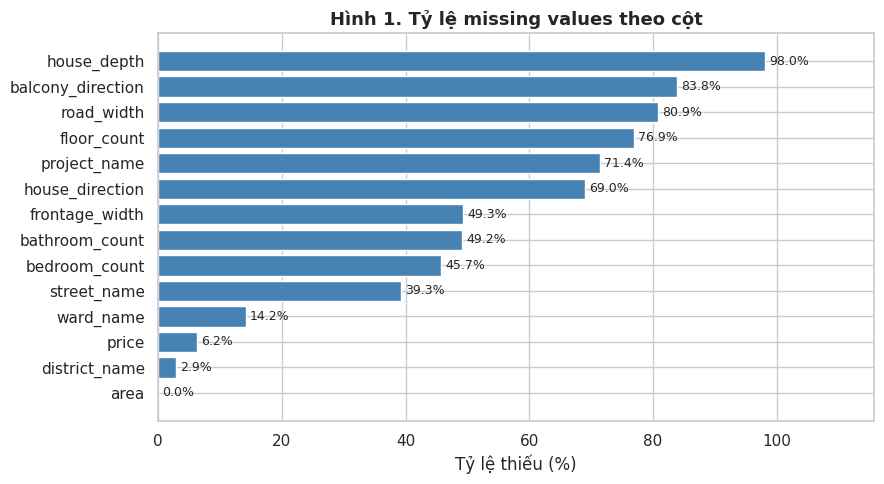

Nhận xét: Các cột floor_count, bedroom_count, bathroom_count thiếu nhiều nhất.
          Cột description, area, price, province_name gần như đầy đủ.


In [40]:
# ── Hình 1: Tỷ lệ missing theo cột ─────────────────────────────────────────
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(missing_pct.index, missing_pct.values, color="steelblue")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlabel("Tỷ lệ thiếu (%)")
ax.set_title("Hình 1. Tỷ lệ missing values theo cột", fontsize=13, fontweight="bold")
ax.set_xlim(0, missing_pct.max() * 1.18)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig1_missing_percent.png", dpi=150)
plt.show()
print("Nhận xét: Các cột floor_count, bedroom_count, bathroom_count thiếu nhiều nhất.")
print("          Cột description, area, price, province_name gần như đầy đủ.")


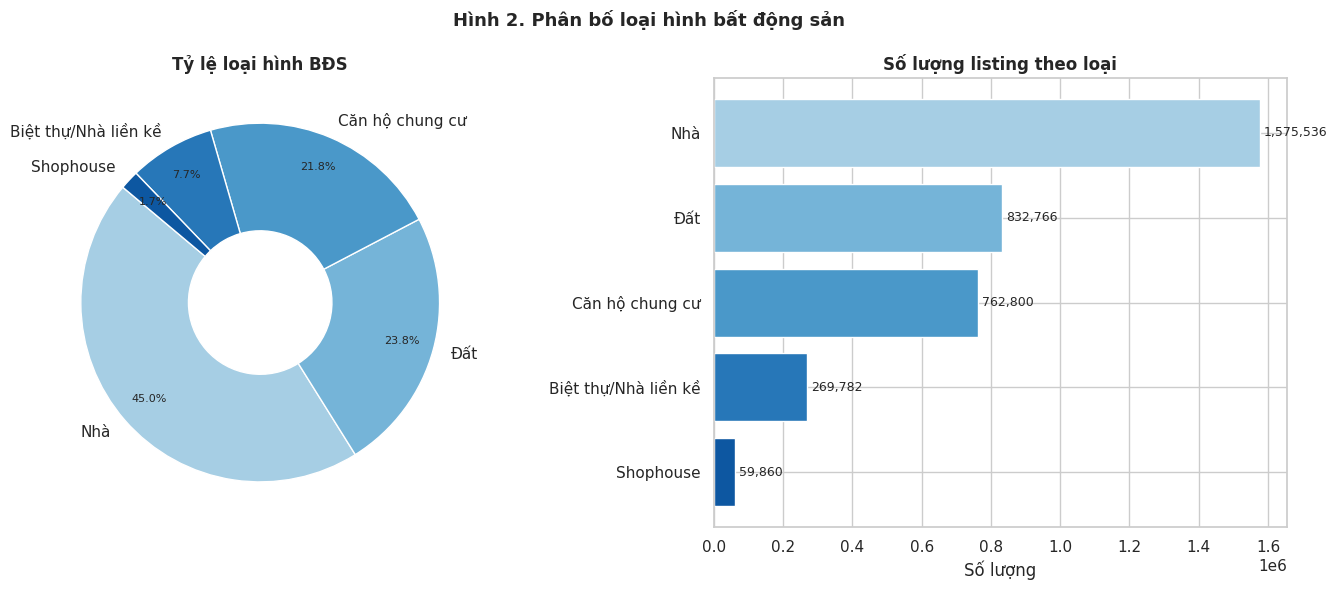

Nhận xét: Nhà ở và Đất chiếm tỷ trọng lớn nhất trong dataset.


In [41]:
# ── Hình 2: Phân bố loại hình BĐS ──────────────────────────────────────────
type_counts = df_raw["property_type_name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(type_counts)))

wedges, texts, autotexts = axes[0].pie(
    type_counts.values, labels=type_counts.index,
    autopct="%1.1f%%", colors=colors, startangle=140,
    pctdistance=0.82, wedgeprops=dict(width=0.6)
)
for t in autotexts: t.set_fontsize(8)
axes[0].set_title("Tỷ lệ loại hình BĐS", fontsize=12, fontweight="bold")

bars = axes[1].barh(type_counts.index[::-1], type_counts.values[::-1], color=colors[::-1])
axes[1].bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
axes[1].set_title("Số lượng listing theo loại", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Số lượng")

fig.suptitle("Hình 2. Phân bố loại hình bất động sản", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig2_property_type.png", dpi=150)
plt.show()
print("Nhận xét: Nhà ở và Đất chiếm tỷ trọng lớn nhất trong dataset.")


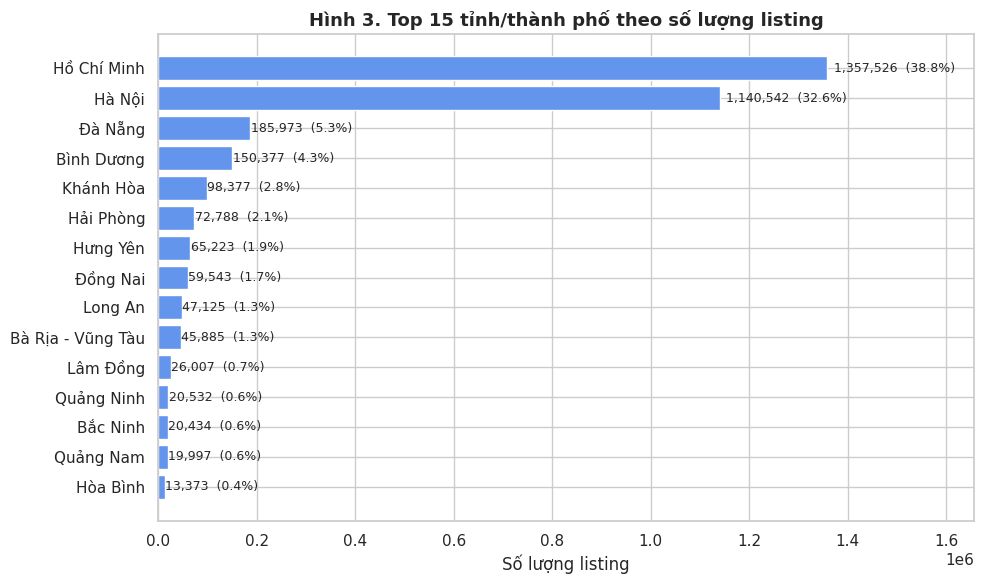

Nhận xét: TP.HCM và Hà Nội chiếm ưu thế vượt trội, phản ánh mức độ đô thị hóa cao.


In [42]:
# ── Hình 3: Top 15 tỉnh thành ───────────────────────────────────────────────
top15_prov = df_raw["province_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15_prov.index[::-1], top15_prov.values[::-1], color="cornflowerblue")
for bar in bars:
    w = bar.get_width()
    pct = w / len(df_raw) * 100
    ax.text(w * 1.01, bar.get_y() + bar.get_height()/2,
            f"{w:,.0f}  ({pct:.1f}%)", va="center", fontsize=9)
ax.set_title("Hình 3. Top 15 tỉnh/thành phố theo số lượng listing",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Số lượng listing")
ax.set_xlim(0, top15_prov.max() * 1.22)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig3_top15_province.png", dpi=150)
plt.show()
print("Nhận xét: TP.HCM và Hà Nội chiếm ưu thế vượt trội, phản ánh mức độ đô thị hóa cao.")


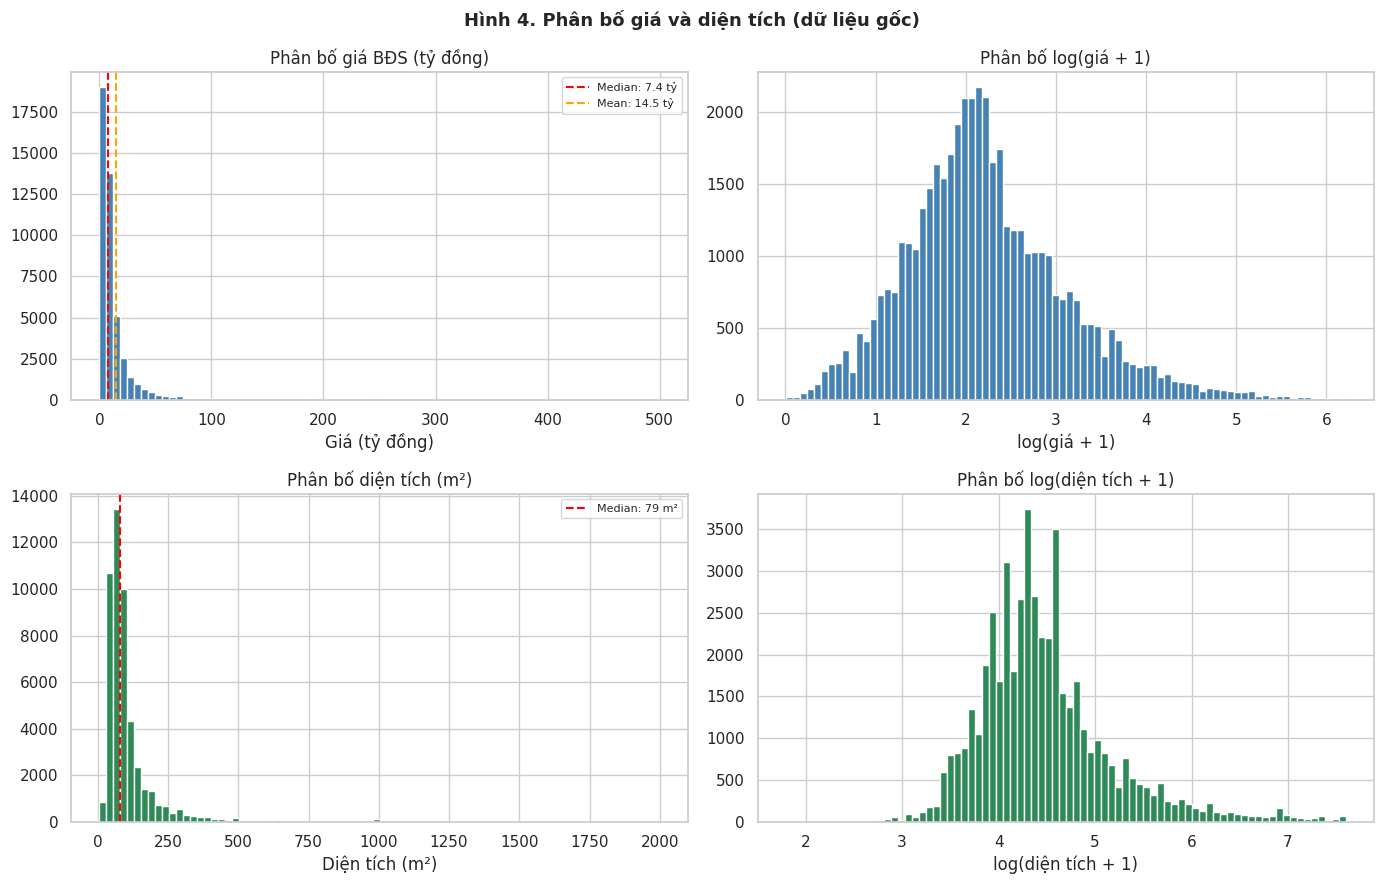

Nhận xét: Giá và diện tích lệch phải mạnh → cần biến đổi log trước khi đưa vào mô hình.


In [43]:
# ── Hình 4: Phân bố giá và diện tích ────────────────────────────────────────
plot_df = df_raw.sample(min(PLOT_SAMPLE_ROWS, len(df_raw)), random_state=RANDOM_STATE).copy()
price_clean = plot_df["price"].dropna()
price_clean = price_clean[(price_clean > 0) & (price_clean <= 500_000_000_000)] / 1e9
area_clean  = plot_df["area"].dropna()
area_clean  = area_clean[(area_clean >= 5) & (area_clean <= 2000)]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Giá gốc
axes[0,0].hist(price_clean, bins=80, color="steelblue", edgecolor="white", lw=0.4)
axes[0,0].axvline(price_clean.median(), color="red", ls="--",
                  label=f"Median: {price_clean.median():.1f} tỷ")
axes[0,0].axvline(price_clean.mean(), color="orange", ls="--",
                  label=f"Mean: {price_clean.mean():.1f} tỷ")
axes[0,0].set_title("Phân bố giá BĐS (tỷ đồng)"); axes[0,0].legend(fontsize=8)
axes[0,0].set_xlabel("Giá (tỷ đồng)")

# Giá log
axes[0,1].hist(np.log1p(price_clean), bins=80, color="steelblue", edgecolor="white", lw=0.4)
axes[0,1].set_title("Phân bố log(giá + 1)")
axes[0,1].set_xlabel("log(giá + 1)")

# Diện tích gốc
axes[1,0].hist(area_clean, bins=80, color="seagreen", edgecolor="white", lw=0.4)
axes[1,0].axvline(area_clean.median(), color="red", ls="--",
                  label=f"Median: {area_clean.median():.0f} m²")
axes[1,0].set_title("Phân bố diện tích (m²)"); axes[1,0].legend(fontsize=8)
axes[1,0].set_xlabel("Diện tích (m²)")

# Diện tích log
axes[1,1].hist(np.log1p(area_clean), bins=80, color="seagreen", edgecolor="white", lw=0.4)
axes[1,1].set_title("Phân bố log(diện tích + 1)")
axes[1,1].set_xlabel("log(diện tích + 1)")

fig.suptitle("Hình 4. Phân bố giá và diện tích (dữ liệu gốc)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig4_price_area_dist.png", dpi=150)
plt.show()
print("Nhận xét: Giá và diện tích lệch phải mạnh → cần biến đổi log trước khi đưa vào mô hình.")


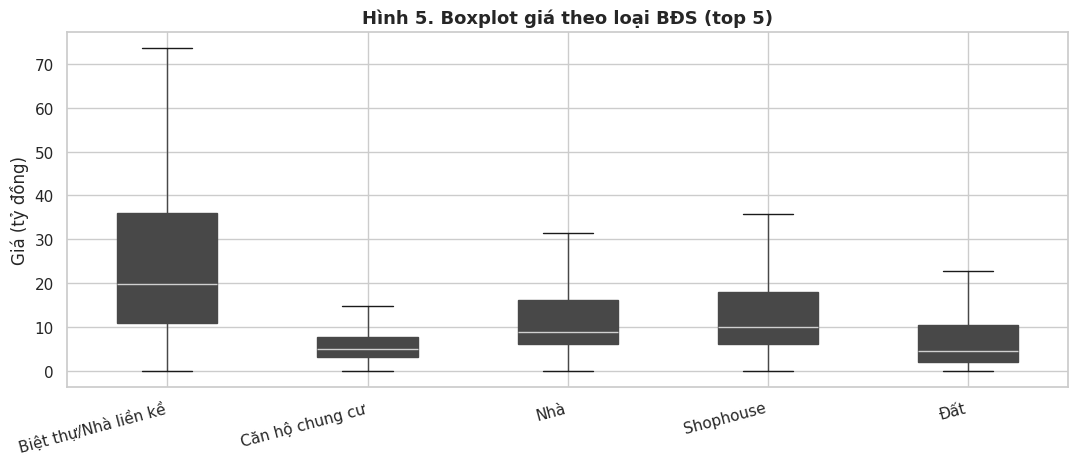

Nhận xét: Biệt thự và nhà mặt phố có giá trung vị cao hơn hẳn đất nền và căn hộ.


In [44]:
# ── Hình 5: Boxplot giá theo loại BĐS top 5 ────────────────────────────────
top5 = df_raw["property_type_name"].value_counts().head(5).index
df_box = df_raw[
    df_raw["property_type_name"].isin(top5) &
    df_raw["price"].notna() &
    (df_raw["price"] > 0) & (df_raw["price"] <= 500_000_000_000)
].copy()
df_box["price_billion"] = df_box["price"] / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
df_box.boxplot(column="price_billion", by="property_type_name",
               ax=ax, showfliers=False, patch_artist=True)
ax.set_title("Hình 5. Boxplot giá theo loại BĐS (top 5)", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Giá (tỷ đồng)")
plt.suptitle(""); plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig5_boxplot_price_type.png", dpi=150)
plt.show()
print("Nhận xét: Biệt thự và nhà mặt phố có giá trung vị cao hơn hẳn đất nền và căn hộ.")


## 2. Chia train/test và lưu dữ liệu thô

Tỷ lệ chia: **90% train / 10% test**, shuffle ngẫu nhiên với `random_state=42`.  
Dữ liệu được lưu ngay vào file CSV trước khi làm sạch để đảm bảo tính tái lập.


In [45]:
if not RAW_TRAIN_PATH.exists() or not RAW_TEST_PATH.exists():
    train_raw, test_raw = train_test_split(df_raw, test_size=0.1,
                                           random_state=RANDOM_STATE, shuffle=True)
    train_raw = train_raw.reset_index(drop=True)
    test_raw  = test_raw.reset_index(drop=True)
    train_raw.to_csv(RAW_TRAIN_PATH, index=False, encoding="utf-8-sig")
    test_raw.to_csv(RAW_TEST_PATH,   index=False, encoding="utf-8-sig")
    print(f"✅ Đã lưu raw split.")
else:
    train_raw = pd.read_csv(RAW_TRAIN_PATH, usecols=USECOLS, nrows=100_000)
    test_raw  = pd.read_csv(RAW_TEST_PATH,  usecols=USECOLS, nrows=20_000)
    print("✅ Đã tồn tại raw split, đọc mẫu để kiểm tra.")

print(f"Train: {RAW_TRAIN_PATH.stat().st_size/1e6:.1f} MB")
print(f"Test : {RAW_TEST_PATH.stat().st_size/1e6:.1f} MB")
print(f"Tỷ lệ thực tế — Train: {len(train_raw):,} / Test: {len(test_raw):,}")


✅ Đã tồn tại raw split, đọc mẫu để kiểm tra.
Train: 2915.3 MB
Test : 324.0 MB
Tỷ lệ thực tế — Train: 100,000 / Test: 20,000


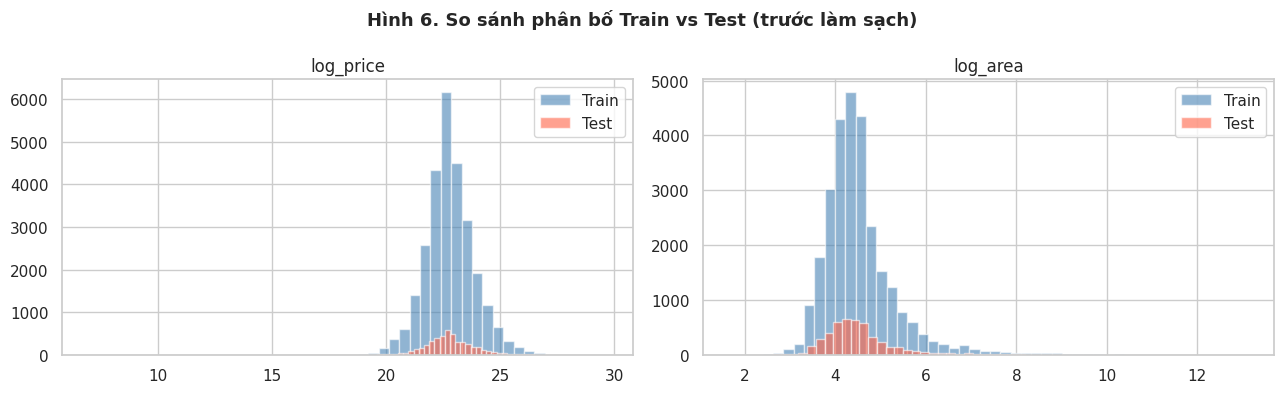

,feature,train_median,test_median
0,price,22.73,22.72
1,area,4.39,4.39


Nhận xét: Phân bố train và test rất tương đồng → không có distribution shift đáng kể.


34107

In [46]:
# ── Hình 6: So sánh phân bố train/test trước làm sạch ───────────────────────
def prep_plot(df_):
    out = df_.copy()
    out["price"] = pd.to_numeric(out["price"], errors="coerce")
    out["area"]  = pd.to_numeric(out["area"],  errors="coerce")
    out = out[(out["price"] > 0) & (out["area"] > 0)].copy()
    out["log_price"] = np.log1p(out["price"])
    out["log_area"]  = np.log1p(out["area"])
    return out

tr_plot = prep_plot(train_raw.sample(min(30_000, len(train_raw)), random_state=RANDOM_STATE))
te_plot = prep_plot(test_raw.sample(min(5_000,  len(test_raw)),  random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for col, ax in zip(["log_price", "log_area"], axes):
    tr_plot[col].hist(bins=50, alpha=0.6, ax=ax, label="Train", color="steelblue")
    te_plot[col].hist(bins=50, alpha=0.6, ax=ax, label="Test",  color="tomato")
    ax.set_title(col); ax.legend()

fig.suptitle("Hình 6. So sánh phân bố Train vs Test (trước làm sạch)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig6_train_test_shift.png", dpi=150)
plt.show()

cmp = pd.DataFrame({
    "feature": ["price", "area"],
    "train_median": [tr_plot["log_price"].median(), tr_plot["log_area"].median()],
    "test_median":  [te_plot["log_price"].median(), te_plot["log_area"].median()],
})
display(cmp)
print("Nhận xét: Phân bố train và test rất tương đồng → không có distribution shift đáng kể.")

del df_raw, tr_plot, te_plot, train_raw, test_raw
gc.collect()


## 3. Trích xuất đặc trưng – Làm sạch dữ liệu

Các bước làm sạch thực hiện theo thứ tự:
1. Chuyển kiểu dữ liệu số và datetime.
2. Chuẩn hóa cột phân loại (fill NaN → "Không rõ").
3. Normalize text: chữ thường, xóa URL, xóa số điện thoại.
4. Fill missing `floor_count`, `bedroom_count`, `bathroom_count`:
   - Ưu tiên 1: theo loại BĐS (Đất → 0, Căn hộ chung cư → 1 tầng).
   - Ưu tiên 2: trích xuất từ `description` bằng regex.
   - Ưu tiên 3: impute bằng median theo `property_type_name` (fit từ train).
   - Ghi nhận flag `floor_missing`, `bedroom_missing`, `bathroom_missing`.
5. Lọc dòng không hợp lệ (thiếu giá, diện tích, quận/phường; giá/diện tích ≤ 0).
6. Loại bỏ trùng lặp.
7. Lọc outlier bằng ngưỡng phân vị 0.5%–99.5% (fit từ train, apply test).

> **Lưu ý anti data leakage:** Toàn bộ ngưỡng outlier và median impute chỉ được học từ tập train rồi áp dụng lại cho tập test.


In [47]:
# ════════════════════════════════════════════════════════════════════════════
# 3.1  HÀM TIỆN ÍCH
# ════════════════════════════════════════════════════════════════════════════

def to_numeric_col(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (series.astype(str)
               .str.replace(",", "", regex=False)
               .str.replace(" ", "", regex=False)
               .str.replace("nan", "", regex=False))
    return pd.to_numeric(cleaned, errors="coerce")


def normalize_text(value):
    """Làm sạch cơ bản một chuỗi văn bản."""
    if pd.isna(value):
        return ""
    s = str(value).lower()
    s = re.sub(r"\[phone_number\]|\bphone_number\b", " ", s)
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


# ── Regex trích xuất số tầng ─────────────────────────────────────────────────
def extract_floor(text):
    if not text:
        return np.nan
    if re.search(r"(nhà\s*)?cấp\s*4", text):
        return 1.0
    m = re.search(r"(\d+)\s*tầng", text)
    if m:
        return float(m.group(1))
    ms = re.findall(r"tầng\s*(\d+)", text)
    if ms:
        return float(ms[-1])
    m = re.search(r"(\d+)\s*lầu", text)
    if m:
        return float(m.group(1)) + 1
    if re.search(r"(nhà\s*)?trệt\s*lầu|trệt\s*\+\s*lầu", text):
        return 2.0
    return np.nan


# ── Regex trích xuất số phòng ngủ ────────────────────────────────────────────
def extract_bedroom(text):
    if not text:
        return np.nan
    m = re.search(r"(\d+)\s*(phòng\s*ngủ|phong\s*ngu|\bpn\b)", text)
    if m:
        return float(m.group(1))
    m = re.search(r"(phòng\s*ngủ|\bpn\b)\s*[:\-]?\s*(\d+)", text)
    if m:
        return float(m.group(2))
    return np.nan


# ── Regex trích xuất số phòng tắm ────────────────────────────────────────────
def extract_bathroom(text):
    if not text:
        return np.nan
    m = re.search(r"(\d+)\s*(phòng\s*tắm|phong\s*tam|\btoilet\b|\bwc\b|nhà\s*vệ\s*sinh)", text)
    if m:
        return float(m.group(1))
    m = re.search(r"(phòng\s*tắm|\btoilet\b|\bwc\b)\s*[:\-]?\s*(\d+)", text)
    if m:
        return float(m.group(2))
    return np.nan


print("✅ Các hàm tiện ích đã sẵn sàng.")


✅ Các hàm tiện ích đã sẵn sàng.


In [48]:
NUMERIC_COLS = ["price", "area", "floor_count"]
CAT_COLS = ["property_type_name", "province_name", "district_name", "ward_name"]

def basic_clean(df_in):
    df = df_in.copy()
    
    # 1. Bỏ hẳn các cột không dùng đến ngay từ đầu (Tối ưu RAM)
    cols_to_drop = [
        "frontage_width", "house_depth", "road_width", 
        "bedroom_count", "bathroom_count", "street_name", 
        "project_name", "house_direction", "balcony_direction"
    ]
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors="ignore")

    # 2. Đồng nhất tất cả rác (empty, nan, null, Không rõ) thành NaN chuẩn
    df = df.replace(to_replace=[r'^\s*$', "nan", "None", "null", "Không rõ"], value=np.nan, regex=True)

    # 3. Xóa NGAY các mẫu trống các cột cốt lõi (Không thể phục hồi)
    required_cols = ["price", "area"] + [col for col in CAT_COLS if col in df.columns]
    df = df.dropna(subset=required_cols)

    # 4. Ép kiểu và lọc giá trị vật lý (Price, Area > 0)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["area"] = pd.to_numeric(df["area"], errors="coerce")
    df = df[(df["price"] > 0) & (df["area"] > 0)]

    # 5. Normalize text description (Dùng cho hàm fill ở bước sau)
    if "description" in df.columns:
        df["description_clean"] = df["description"].apply(normalize_text)
    else:
        df["description_clean"] = ""

    return df.reset_index(drop=True)


def fill_missing_counts(df_in):
    """
    Phục hồi floor_count theo 2 ưu tiên:
      1) Theo loại BĐS (Đất=0, Căn hộ chung cư=1 tầng)
      2) Regex từ description_clean
    Sau đó XÓA TẤT CẢ các dòng vẫn bị thiếu floor_count.
    """
    df = df_in.copy()
    
    if "floor_count" not in df.columns:
        return df

    df["floor_count"] = pd.to_numeric(df["floor_count"], errors="coerce")

    # ── Ưu tiên 1: Theo loại BĐS ────────────────────────────────────────────
    is_dat = df["property_type_name"].str.lower().str.contains("đất", na=False)
    is_ch  = df["property_type_name"].str.lower().str.contains("chung cư|căn hộ", na=False)

    df.loc[is_dat & df["floor_count"].isna(), "floor_count"] = 0.0
    df.loc[is_ch  & df["floor_count"].isna(), "floor_count"] = 1.0

    # ── Ưu tiên 2: Regex từ description ─────────────────────────────────────
    if "description_clean" in df.columns:
        # Chỉ chạy apply trên những dòng CÒN THIẾU để tối ưu tốc độ
        missing_mask = df["floor_count"].isna()
        if missing_mask.sum() > 0:
            df.loc[missing_mask, "floor_count"] = df.loc[missing_mask, "description_clean"].apply(extract_floor)

    # ── Bước then chốt: Xóa sạch các mẫu vẫn thiếu (Không điền giả tạo) ─────
    df = df.dropna(subset=["floor_count"])

    return df.reset_index(drop=True)


def fit_cleaning_rules(df_in):
    """Học ngưỡng outlier từ tập train đã basic_clean."""
    rules = {}
    for col in ["price", "area"]:
        rules[col] = {
            "lower": float(df_in[col].quantile(0.01)),
            "upper": float(df_in[col].quantile(0.99)),
        }
    return rules


def apply_cleaning_rules(df_in, rules):
    mask = pd.Series(True, index=df_in.index)
    for col, bounds in rules.items():
        if col in df_in.columns:
            mask &= df_in[col].between(bounds["lower"], bounds["upper"])
    return df_in.loc[mask].reset_index(drop=True)

print("✅ Các hàm làm sạch đã sẵn sàng.")

✅ Các hàm làm sạch đã sẵn sàng.


In [49]:
import gc
import json

# ════════════════════════════════════════════════════════════════════════════
# 3.3  ÁP DỤNG LÀM SẠCH THEO CHUNK
# ════════════════════════════════════════════════════════════════════════════

def clean_csv_chunks(input_path, output_path, rules,
                     chunksize=50_000, sample_rows=None, random_state=42):
    """Làm sạch file CSV lớn theo chunk, lưu ra file mới."""
    rng = np.random.default_rng(random_state)
    parts, sampled, total_in, total_out = [], 0, 0, 0
    first = True

    for chunk in pd.read_csv(input_path, usecols=USECOLS, chunksize=chunksize):
        total_in += len(chunk)
        
        # 1. Làm sạch cơ bản (Ép kiểu, xóa NaN lõi)
        c = basic_clean(chunk)
        # 2. Điền floor_count & xóa dòng vẫn thiếu
        c = fill_missing_counts(c)
        # 3. Cắt Outlier
        c = apply_cleaning_rules(c, rules)
        
        # 4. Loại bỏ duplicate
        c = c.drop_duplicates().reset_index(drop=True)
        # Đã xóa dòng: c = c.drop(columns=["_ppm2"], errors="ignore")
        
        total_out += len(c)

        c.to_csv(output_path, mode="w" if first else "a",
                 header=first, index=False,
                 encoding="utf-8-sig" if first else "utf-8")
        first = False

        if sample_rows and sampled < sample_rows and len(c) > 0:
            need = min(sample_rows - sampled, len(c))
            parts.append(c.sample(need, random_state=int(rng.integers(0, 1_000_000))))
            sampled += need

        del chunk, c; gc.collect()

    sample_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    print(f"  {input_path.name}: {total_in:,} → {total_out:,} dòng sạch")
    return sample_df


# ── Bước 1: Fit rules từ mẫu train ──────────────────────────────────────────
print("Đang fit cleaning rules từ train sample...")
sample_for_fit = pd.read_csv(RAW_TRAIN_PATH, usecols=USECOLS, nrows=200_000)
sample_basic   = basic_clean(sample_for_fit)
sample_basic   = fill_missing_counts(sample_basic) # Cập nhật cách gọi hàm
cleaning_rules = fit_cleaning_rules(sample_basic)

print("Ngưỡng outlier học được từ train:")
for col, b in cleaning_rules.items():
    print(f"  {col}: [{b['lower']:,.0f} — {b['upper']:,.0f}]")

# Chỉ lưu lại cleaning_rules
with open(MODEL_DIR / "cleaning_rules.json", "w", encoding="utf-8") as f:
    json.dump(cleaning_rules, f, ensure_ascii=False, indent=2)

del sample_for_fit, sample_basic; gc.collect()

# ── Bước 2: Làm sạch toàn bộ train và test ──────────────────────────────────
print("\nĐang làm sạch tập train...")
clean_train = clean_csv_chunks(RAW_TRAIN_PATH, CLEAN_TRAIN_PATH,
                               cleaning_rules, # Gỡ median_map
                               chunksize=CHUNK_SIZE, sample_rows=MAX_MODEL_ROWS)

print("Đang làm sạch tập test...")
clean_test = clean_csv_chunks(RAW_TEST_PATH,  CLEAN_TEST_PATH,
                              cleaning_rules,  # Gỡ median_map
                              chunksize=CHUNK_SIZE, sample_rows=50_000)

print(f"\n✅ clean_train in RAM: {clean_train.shape}")
print(f"✅ clean_test  in RAM: {clean_test.shape}")
print(f"✅ Lưu: {CLEAN_TRAIN_PATH}")
print(f"✅ Lưu: {CLEAN_TEST_PATH}")

Đang fit cleaning rules từ train sample...
Ngưỡng outlier học được từ train:
  price: [560,000,000 — 140,000,000,000]
  area: [25 — 2,477]

Đang làm sạch tập train...
  raw_data_train.csv: 3,150,669 → 2,214,993 dòng sạch
Đang làm sạch tập test...
  raw_data_test.csv: 350,075 → 245,636 dòng sạch

✅ clean_train in RAM: (300000, 11)
✅ clean_test  in RAM: (50000, 11)
✅ Lưu: /kaggle/working/data/clean/clean_data_train.csv
✅ Lưu: /kaggle/working/data/clean/clean_data_test.csv


In [50]:
# ── Báo cáo kết quả làm sạch ────────────────────────────────────────────────
before_rows = sum(1 for _ in open(RAW_TRAIN_PATH)) - 1
after_rows  = sum(1 for _ in open(CLEAN_TRAIN_PATH)) - 1

print("=== Kết quả làm sạch tập train ===")
print(f"  Trước làm sạch : {before_rows:,} dòng")
print(f"  Sau làm sạch   : {after_rows:,} dòng")
print(f"  Đã loại bỏ     : {before_rows - after_rows:,} dòng ({(before_rows-after_rows)/before_rows*100:.1f}%)")

print("\n=== Tỷ lệ missing sau làm sạch (mẫu in-RAM) ===")
miss_after = (clean_train.isna().mean() * 100).sort_values(ascending=False)
display(miss_after[miss_after > 0].to_frame("missing %"))

display(clean_train.head(3))


=== Kết quả làm sạch tập train ===
  Trước làm sạch : 3,150,669 dòng
  Sau làm sạch   : 2,214,993 dòng
  Đã loại bỏ     : 935,676 dòng (29.7%)

=== Tỷ lệ missing sau làm sạch (mẫu in-RAM) ===


,missing %
description,0.21
name,0.12


,name,description,property_type_name,province_name,district_name,ward_name,price,area,floor_count,published_at,description_clean
0,"Đất nền bán tại Đường 234 ấp 4, An Viễn, Trảng...","Bán đất nền tại Đường 234 Ấp 4, Xã An Viễn, Tr...",Đất,Đồng Nai,Trảng Bom,An Viễn,"1,960,000,000.00",150.00,0.00,2025-12-23T15:16:19.189000,"bán đất nền tại đường 234 ấp 4, xã an viễn, tr..."
1,"Siêu đẹp, ngon về giá chỉ 1,1x tỷ có ngay lô đ...","Siêu đẹp, ngon về giá chỉ 1,1x tỷ có ngay lô đ...",Đất,Hà Nội,Chương Mỹ,Phú Nghĩa,"1,190,000,000.00",62.50,0.00,2025-08-20T13:46:18.901000,"siêu đẹp, ngon về giá chỉ 1,1x tỷ có ngay lô đ..."
2,"Bán đất tại Hiệp Thành, 3.35 tỷ, 126m2, khu vự...","Đất nền tại phường Phú Lợi, Hồ Chí Minh - Thàn...",Đất,Bình Dương,Thủ Dầu Một,Hiệp Thành,"3,350,000,000.00",126.00,0.00,2026-03-25T08:47:52.782000,"đất nền tại phường phú lợi, hồ chí minh - thàn..."


## 3. Trích xuất đặc trưng – Feature Engineering

Từ dữ liệu đã làm sạch, tạo thêm các đặc trưng mới:

| Nhóm | Đặc trưng |
|---|---|
| Log transform | `log_price`, `log_area`, `log_price_per_m2` |
| Giá phái sinh | `price_per_m2` |
| Thời gian | `published_month`, `published_quarter` |
| Nhị phân từ text | `has_elevator`, `suitable_for_car`, `has_legal_document`, `has_full_furniture`, `near_sea`, `near_transport`, `near_public_services`, `business_potential` |
| Địa lý (target encoding) | `district_encoded`, `ward_encoded` (giá/m² trung bình theo quận/phường, fit từ train) |
| Flag missing | `floor_missing`, `bedroom_missing`, `bathroom_missing` |


In [51]:
import numpy as np
import pandas as pd
import json

# ════════════════════════════════════════════════════════════════════════════
# 4. FEATURE ENGINEERING TỔNG HỢP
# ════════════════════════════════════════════════════════════════════════════

def feature_engineering(df_in, encoding_map=None, fit=False):
    df = df_in.copy()

    # ── 1. Đảm bảo cột text chuẩn bị sẵn ────────────────────────────────────
    if "description_clean" in df.columns:
        text = df["description_clean"].fillna("").astype(str).str.lower()
    elif "description" in df.columns:
        text = df["description"].fillna("").astype(str).str.lower()
    else:
        text = pd.Series([""] * len(df))

    # ── 2. Biến đổi Logarit & Tính Giá/m2 ───────────────────────────────────
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["area"] = pd.to_numeric(df["area"], errors="coerce")
    df["price_per_m2"] = df["price"] / df["area"]

    df["log_price"] = np.log1p(df["price"])
    df["log_area"] = np.log1p(df["area"])
    df["log_price_per_m2"] = np.log1p(df["price_per_m2"])

    # ── 3. Trích xuất đặc trưng Nhị phân (Regex siêu tốc) ───────────────────
    luxury_kw = ["hồ bơi", "bể bơi", "sân golf", "tennis", "kayak", "sauna", "spa", "gym", "xông hơi", "hầm rượu", "clubhouse", "bến du thuyền", "compound", "khép kín", "biệt lập", "song lập", "hoàng gia", "châu âu", "tân cổ điển"]
    affordable_kw = ["xe máy tránh", "ba gác", "ngõ 2m", "ngõ 3m", "ngõ nhỏ", "hẻm nhỏ", "hẻm 2m", "hẻm 3m", "kiệt", "ngách", "cấp 4", "tiện xây mới", "gác lửng", "cũ", "tầm tiền", "tầm tài chính", "ngõ xe máy", "cụt", "ngõ sâu", "cách đường ô tô"]
    commercial_kw = ["kinh doanh", "buôn bán", "sầm uất", "shophouse", "shop house", "mặt bằng", "dòng tiền", "hiệu suất", "thu nhập", "khoán", "văn phòng", "tòa văn phòng", "lô góc", "mặt phố", "hai mặt tiền", "2 mặt tiền"]
    car_kw = ["gara", "ga ra", "garage", "ô tô", "xe con", "xe hơi", "oto", "o to", "đỗ xe", "parking", "đậu xe", "giữ xe", "hẻm ô tô"]
    transport_kw = ["bus", "buýt", "nhà ga", "bến xe", "metro", "sân bay", "ga tàu", "bến tàu", "quốc lộ", "cao tốc", "đường lớn", "trục đường chính", "trạm dừng", "bến dừng"]
    sea_kw = ["view biển", "biển", "seaview", "bãi tắm", "mỹ khê", "non nước", "xuân thiều", "nam ô", "sơn trà", "sầm sơn", "bãi dài", "dốc lết", "bãi trước", "bãi sau", "kỳ co", "eo gió", "đồ sơn", "bãi sao", "bãi kem", "bãi trường", "bãi cháy", "tuần châu", "an bàng", "cửa đại", "mũi né", "tuy hòa", "bãi xép", "cát bà"]
    public_kw = ["trường học", "đại học", "mầm non", "thpt", "thcs", "tiểu học", "bệnh viện", "bệnh xá", "trung tâm y tế", "chợ", "siêu thị", "công viên", "trung tâm thương mại", "trung tâm mua sắm"]

    df["has_luxury_amenities"] = text.str.contains("|".join(luxury_kw), regex=True, na=False).astype(int)
    df["is_affordable"]        = text.str.contains("|".join(affordable_kw), regex=True, na=False).astype(int)
    df["is_commercial"]        = text.str.contains("|".join(commercial_kw), regex=True, na=False).astype(int)
    df["suitable_for_car"]     = text.str.contains("|".join(car_kw), regex=True, na=False).astype(int)
    df["near_transport_hub"]   = text.str.contains("|".join(transport_kw), regex=True, na=False).astype(int)
    df["near_sea"]             = text.str.contains("|".join(sea_kw), regex=True, na=False).astype(int)
    df["has_public_amenities"] = text.str.contains("|".join(public_kw), regex=True, na=False).astype(int)

    # ── 4. Target Encoding: Tỉnh, Quận, Phường ──────────────────────────────
    if fit:
        encoding_map = {
            "province_mean": df.groupby("province_name")["price_per_m2"].mean().to_dict() if "province_name" in df.columns else {},
            "district_mean": df.groupby("district_name")["price_per_m2"].mean().to_dict() if "district_name" in df.columns else {},
            "ward_mean":     df.groupby("ward_name")["price_per_m2"].mean().to_dict() if "ward_name" in df.columns else {},
            "global_mean":   df["price_per_m2"].mean()
        }

    if encoding_map is not None:
        g_mean = encoding_map.get("global_mean", 0)
        if "province_name" in df.columns:
            df["province_encoded"] = df["province_name"].map(encoding_map.get("province_mean", {})).fillna(g_mean)
        if "district_name" in df.columns:
            df["district_encoded"] = df["district_name"].map(encoding_map.get("district_mean", {})).fillna(g_mean)
        if "ward_name" in df.columns:
            df["ward_encoded"]     = df["ward_name"].map(encoding_map.get("ward_mean", {})).fillna(g_mean)

    return df, encoding_map


# ── THỰC THI (ÁP DỤNG LÊN DỮ LIỆU ĐÃ CLEAN) ──────────────────────────────────

print("Đang thực hiện Feature Engineering trên tập train...")
clean_train, enc_map = feature_engineering(clean_train, fit=True)

print("Đang thực hiện Feature Engineering trên tập test...")
clean_test, _ = feature_engineering(clean_test, encoding_map=enc_map, fit=False)

# Lưu encoding map để dùng sau này (Pipeline predict)
with open(MODEL_DIR / "encoding_map.json", "w", encoding="utf-8") as f:
    json.dump(enc_map, f, ensure_ascii=False, indent=2)

print(f"\n✅ clean_train sau feature engineering: {clean_train.shape}")
print(f"✅ clean_test  sau feature engineering: {clean_test.shape}")

Đang thực hiện Feature Engineering trên tập train...
Đang thực hiện Feature Engineering trên tập test...

✅ clean_train sau feature engineering: (300000, 25)
✅ clean_test  sau feature engineering: (50000, 25)


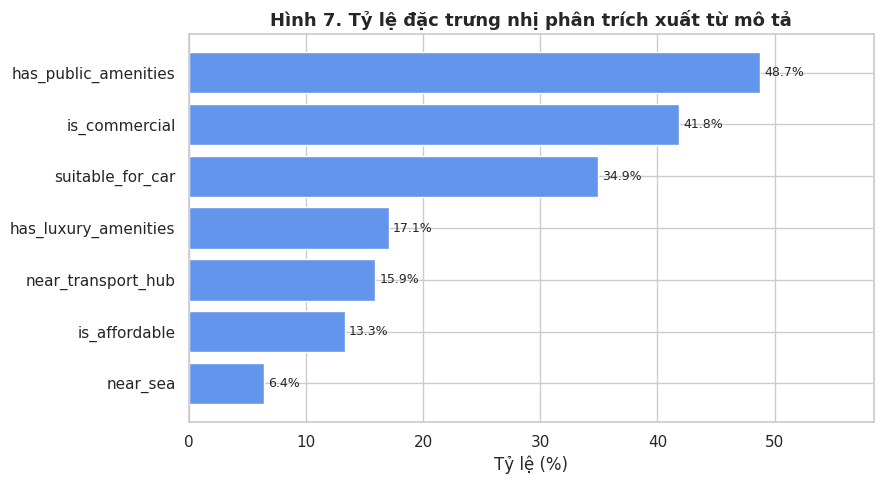

Nhận xét: 


In [52]:
# ── Hình 7: Tỷ lệ đặc trưng nhị phân từ text ───────────────────────────────
binary_cols = [
    'has_luxury_amenities',
    'is_affordable',
    'is_commercial',
    'suitable_for_car',
    'near_transport_hub',
    'near_sea',
    'has_public_amenities'
]
rates = clean_train[binary_cols].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rates.index, rates.values * 100, color="cornflowerblue")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlabel("Tỷ lệ (%)")
ax.set_title("Hình 7. Tỷ lệ đặc trưng nhị phân trích xuất từ mô tả",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, rates.max() * 120)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig7_binary_feature_rates.png", dpi=150)
plt.show()
print("Nhận xét: ")


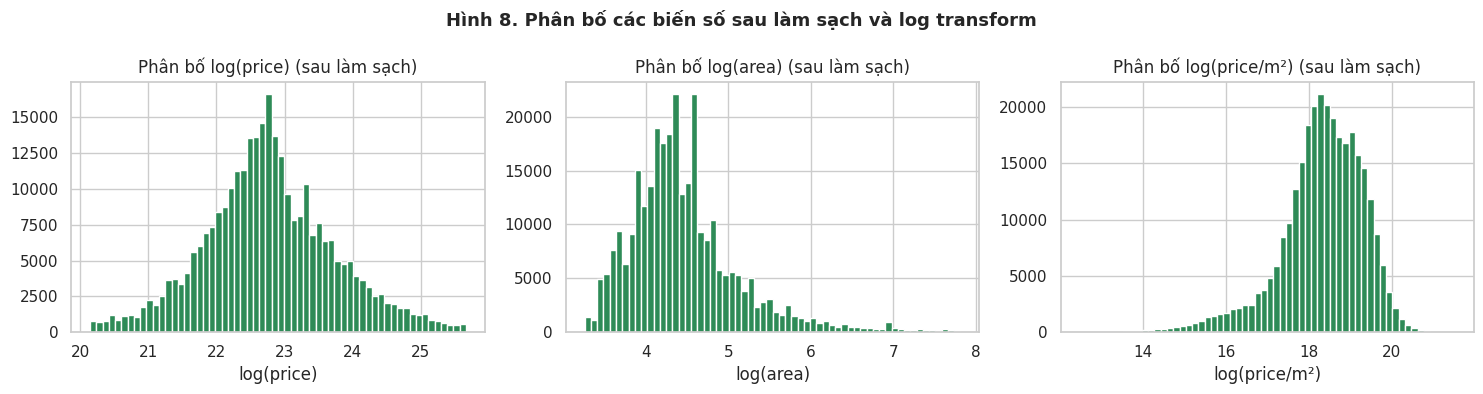

Nhận xét: Sau biến đổi log, phân bố gần chuẩn hơn → thuận lợi cho thuật toán phân cụm.


In [53]:
# ── Hình 8: Phân bố sau làm sạch so với trước ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
    ["log_price","log_area","log_price_per_m2"],
    ["log(price)","log(area)","log(price/m²)"]):
    clean_train[col].hist(bins=60, ax=ax, color="seagreen", edgecolor="white", lw=0.3)
    ax.set_title(f"Phân bố {label} (sau làm sạch)")
    ax.set_xlabel(label)

fig.suptitle("Hình 8. Phân bố các biến số sau làm sạch và log transform",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig8_clean_distributions.png", dpi=150)
plt.show()
print("Nhận xét: Sau biến đổi log, phân bố gần chuẩn hơn → thuận lợi cho thuật toán phân cụm.")


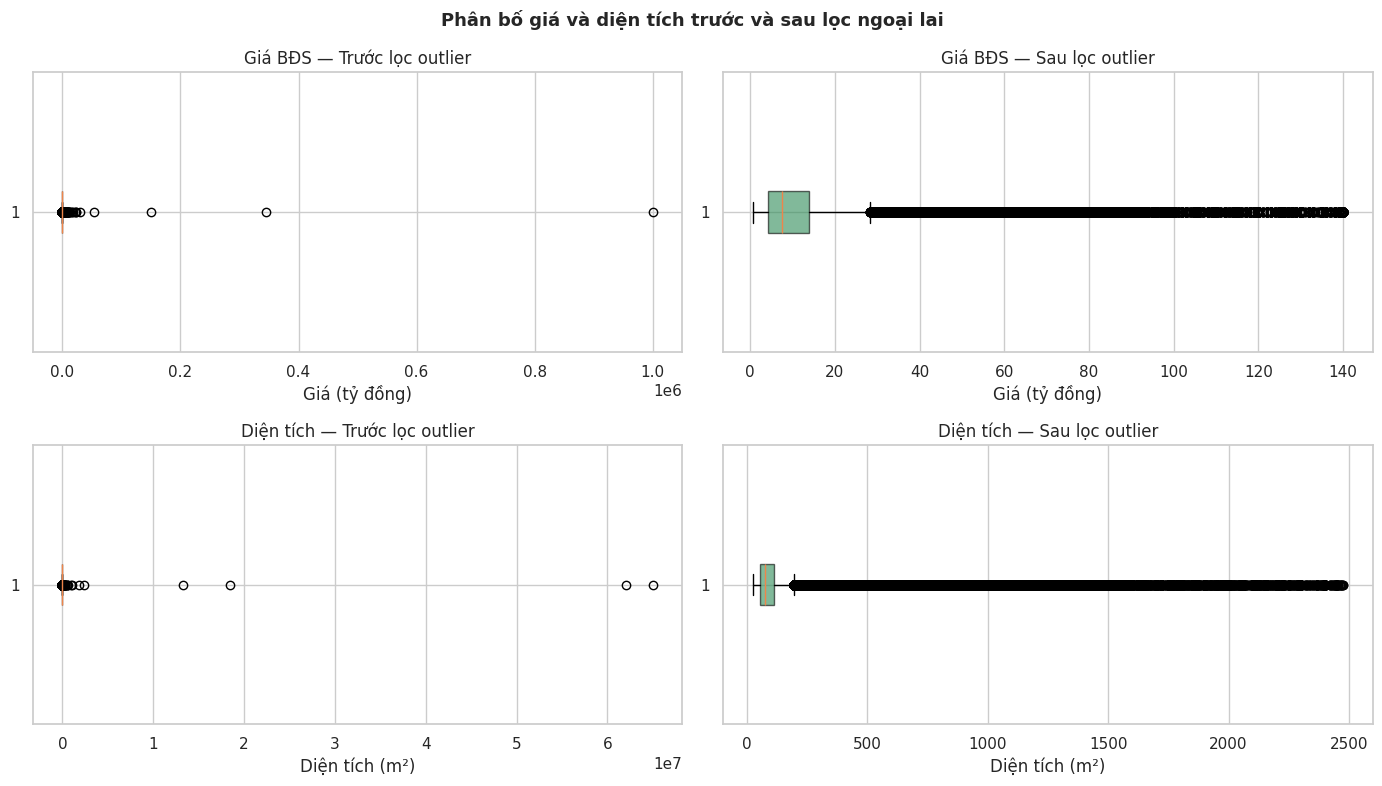

Trước: 276,269 mẫu → Sau: 300,000 mẫu
Đã loại: -23,731 mẫu ngoại lai


In [54]:


train_raw_sample = pd.read_csv(RAW_TRAIN_PATH, usecols=["price", "area"], nrows=300_000)

train_raw_sample["price"] = pd.to_numeric(train_raw_sample["price"], errors="coerce")

train_raw_sample["area"]  = pd.to_numeric(train_raw_sample["area"],  errors="coerce")

train_raw_sample = train_raw_sample[(train_raw_sample["price"] > 0) & (train_raw_sample["area"] > 0)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Giá trước

axes[0, 0].boxplot(

    train_raw_sample["price"].dropna() / 1e9,

    vert=False, showfliers=True, patch_artist=True,

    boxprops=dict(facecolor="steelblue", alpha=0.6)

)

axes[0, 0].set_title("Giá BĐS — Trước lọc outlier")

axes[0, 0].set_xlabel("Giá (tỷ đồng)")

# Giá sau

axes[0, 1].boxplot(

    clean_train["price"].dropna() / 1e9,

    vert=False, showfliers=True, patch_artist=True,

    boxprops=dict(facecolor="seagreen", alpha=0.6)

)

axes[0, 1].set_title("Giá BĐS — Sau lọc outlier")

axes[0, 1].set_xlabel("Giá (tỷ đồng)")

# Diện tích trước

axes[1, 0].boxplot(

    train_raw_sample["area"].dropna(),

    vert=False, showfliers=True, patch_artist=True,

    boxprops=dict(facecolor="steelblue", alpha=0.6)

)

axes[1, 0].set_title("Diện tích — Trước lọc outlier")

axes[1, 0].set_xlabel("Diện tích (m²)")

# Diện tích sau

axes[1, 1].boxplot(

    clean_train["area"].dropna(),

    vert=False, showfliers=True, patch_artist=True,

    boxprops=dict(facecolor="seagreen", alpha=0.6)

)

axes[1, 1].set_title("Diện tích — Sau lọc outlier")

axes[1, 1].set_xlabel("Diện tích (m²)")

fig.suptitle("Phân bố giá và diện tích trước và sau lọc ngoại lai",

             fontsize=13, fontweight="bold")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "figA_outlier_before_after.png", dpi=150)

plt.show()

print(f"Trước: {len(train_raw_sample):,} mẫu → Sau: {len(clean_train):,} mẫu")

print(f"Đã loại: {len(train_raw_sample) - len(clean_train):,} mẫu ngoại lai")

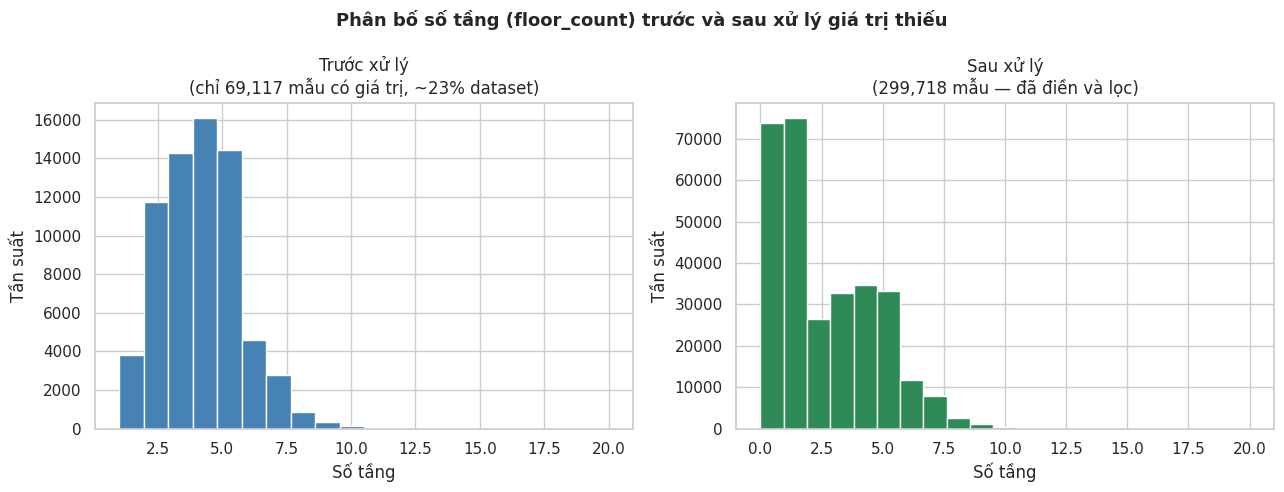

Nhận xét: Sau xử lý, floor_count = 0 (đất nền) chiếm tỷ lệ lớn nhất,
          phản ánh đúng cơ cấu dataset với đất nền là loại hình phổ biến.


In [55]:

train_raw_floor = pd.read_csv(RAW_TRAIN_PATH, usecols=["floor_count"], nrows=300_000)
train_raw_floor["floor_count"] = pd.to_numeric(train_raw_floor["floor_count"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trước
floor_before = train_raw_floor["floor_count"].dropna()
floor_before = floor_before[(floor_before >= 1) & (floor_before <= 20)]
axes[0].hist(floor_before, bins=20, color="steelblue", edgecolor="white", lw=0.4)
axes[0].set_title(f"Trước xử lý\n(chỉ {len(floor_before):,} mẫu có giá trị, ~23% dataset)")
axes[0].set_xlabel("Số tầng")
axes[0].set_ylabel("Tần suất")

# Sau
floor_after = clean_train["floor_count"].dropna()
floor_after = floor_after[(floor_after >= 0) & (floor_after <= 20)]
axes[1].hist(floor_after, bins=21, color="seagreen", edgecolor="white", lw=0.4)
axes[1].set_title(f"Sau xử lý\n({len(floor_after):,} mẫu — đã điền và lọc)")
axes[1].set_xlabel("Số tầng")
axes[1].set_ylabel("Tần suất")

fig.suptitle("Phân bố số tầng (floor_count) trước và sau xử lý giá trị thiếu",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figD_floor_count_before_after.png", dpi=150)
plt.show()
print("Nhận xét: Sau xử lý, floor_count = 0 (đất nền) chiếm tỷ lệ lớn nhất,")
print("          phản ánh đúng cơ cấu dataset với đất nền là loại hình phổ biến.")

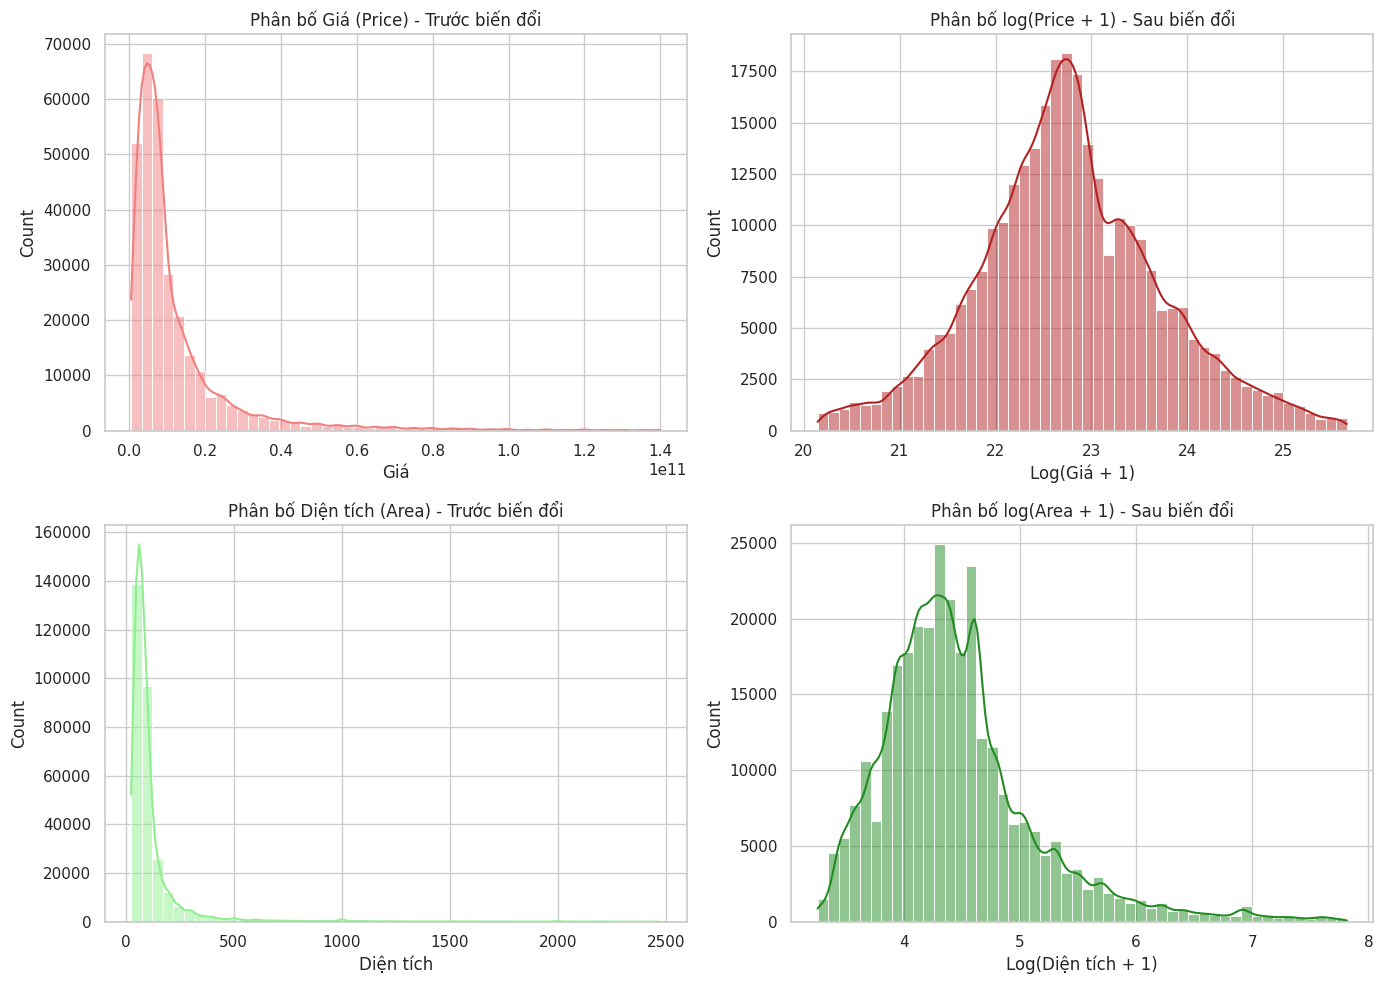

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trực quan hóa Price
sns.histplot(clean_train['price'], bins=50, kde=True, ax=axes[0,0], color='lightcoral')
axes[0,0].set_title('Phân bố Giá (Price) - Trước biến đổi', fontsize=12)
axes[0,0].set_xlabel('Giá')

sns.histplot(np.log1p(clean_train['price']), bins=50, kde=True, ax=axes[0,1], color='firebrick')
axes[0,1].set_title('Phân bố log(Price + 1) - Sau biến đổi', fontsize=12)
axes[0,1].set_xlabel('Log(Giá + 1)')

# Trực quan hóa Area
sns.histplot(clean_train['area'], bins=50, kde=True, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Phân bố Diện tích (Area) - Trước biến đổi', fontsize=12)
axes[1,0].set_xlabel('Diện tích')

sns.histplot(np.log1p(clean_train['area']), bins=50, kde=True, ax=axes[1,1], color='forestgreen')
axes[1,1].set_title('Phân bố log(Area + 1) - Sau biến đổi', fontsize=12)
axes[1,1].set_xlabel('Log(Diện tích + 1)')

plt.tight_layout()
plt.show()

In [57]:
# Giả sử 'df_train' là dữ liệu của bạn trước khi đưa vào pipeline
# Bảng này minh hoạ giá trị Target Encoding đã được tính toán ra sao
target_encode_demo = clean_train.groupby('district_name')['price_per_m2'].mean().reset_index()
target_encode_demo.rename(columns={'price_per_m2': 'encoded_value (Mean Price)'}, inplace=True)

# Lấy ngẫu nhiên 5-6 quận để đưa vào báo cáo
print(target_encode_demo.sample(6, random_state=42).to_markdown(index=False))

# Giả sử bạn lấy 5 mẫu dữ liệu gốc đại diện cho các loại hình
sample_df = clean_train[['property_type_name']].drop_duplicates().head(6)

# Dùng get_dummies để demo nhanh cho báo cáo (bản chất giống OneHotEncoder trong pipeline)
ohe_demo = pd.get_dummies(sample_df['property_type_name'], prefix='is')

# Ghép lại để thấy Trước và Sau
result_demo = pd.concat([sample_df, ohe_demo], axis=1)
print("\n")
print(result_demo.to_markdown(index=False))

| district_name   |   encoded_value (Mean Price) |
|:----------------|-----------------------------:|
| Phủ Lý          |                  5.46376e+07 |
| Đắk R'Lấp       |                  1.00925e+06 |
| Văn Lãng        |                  7.79347e+06 |
| Hòa Vang        |                  1.63895e+07 |
| Định Quán       |                  3.24166e+06 |
| Gò Công Đông    |                  7.70263e+06 |


| property_type_name   | is_Biệt thự/Nhà liền kề   | is_Căn hộ chung cư   | is_Nhà   | is_Shophouse   | is_Đất   |
|:---------------------|:--------------------------|:---------------------|:---------|:---------------|:---------|
| Đất                  | False                     | False                | False    | False          | True     |
| Nhà                  | False                     | False                | True     | False          | False    |
| Căn hộ chung cư      | False                     | True                 | False    | False          | False    |
| Biệt thự/Nhà 

## 4. Mô hình hóa dữ liệu

### 4.1 Xây dựng pipeline trích xuất đặc trưng

Pipeline xử lý 4 nhóm đặc trưng song song qua `ColumnTransformer`:
- **Số**: impute median → StandardScaler.
- **Phân loại**: impute mode → OneHotEncoder.
- **Nhị phân**: impute mode (không scale, đã là 0/1).
- **Text**: TF-IDF (800 features, unigram + bigram) từ `description_clean`.

Sau đó toàn bộ được giảm chiều bằng **TruncatedSVD(15)** → StandardScaler.


In [58]:
NUMERIC_FEATURES = [
    'log_price',
    'log_area',
    'log_price_per_m2',
    'floor_count',
    'province_encoded',
    'district_encoded',
    'ward_encoded'
]

CATEGORICAL_FEATURES = ["property_type_name"]

BINARY_FEATURES = [
    'has_luxury_amenities',
    'is_affordable',
    'is_commercial',
    'suitable_for_car',
    'near_transport_hub',
    'near_sea',
    'has_public_amenities'
]

# Đổi tên flag cho khớp với tên cột đã tạo
for df_ in [clean_train, clean_test]:
    for c in ["floor_count"]:
        old = f"{c}_missing"
        if old in df_.columns and old not in BINARY_FEATURES:
            pass  # đã đúng

# 1. Các pipeline cơ sở
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # Không cần scaler ở đây vì ta sẽ scale toàn bộ ở bước cuối
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False)),
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

# 2. Pipeline xử lý Text: Bơm TF-IDF xong ép nén SVD luôn ở trong cụm này
text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=800, min_df=5, max_df=0.85, ngram_range=(1, 2))),
    ("svd", TruncatedSVD(n_components=15, random_state=RANDOM_STATE)) # Chỉ dùng 15 chiều cho văn bản
])

# 3. Column Transformer: Gộp 4 luồng dữ liệu lại
preprocessor = ColumnTransformer([
    ("num",  numeric_pipeline,      NUMERIC_FEATURES),       # 7 cột
    ("cat",  categorical_pipeline,  CATEGORICAL_FEATURES),   # X cột OHE
    ("bin",  binary_pipeline,       BINARY_FEATURES),        # 7 cột
    ("text", text_pipeline,         "description_clean"),    # 15 cột SVD từ Text
], remainder="drop")

# 4. Feature Pipeline Tổng
feature_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("scaler",     StandardScaler()), # Chuẩn hóa đồng đều toàn bộ ma trận (Số, Chữ, Nhị phân)
])

# ── Fit pipeline trên train ──────────────────────────────────────────────────
if len(clean_train) > MAX_MODEL_ROWS:
    model_train = clean_train.sample(MAX_MODEL_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    model_train = clean_train.copy()

print(f"Số mẫu dùng fit pipeline: {len(model_train):,}")

# Biến đổi dữ liệu
X_model = feature_pipeline.fit_transform(model_train)

# ── FEATURE WEIGHTING (TUYỆT CHIÊU TÁCH CỤM) ──
# Dựa vào NUMERIC_FEATURES, index 0 là log_price, 1 là log_area, 2 là log_price_per_m2
# Ta nhân trọng số lên 3.0 lần để K-Means ưu tiên phân chia theo Giá và Diện tích hơn là theo Chữ
X_model[:, 0] *= 1.0  # log_price
X_model[:, 1] *= 1.0  # log_area
X_model[:, 2] *= 1.0  # log_price_per_m2

print(f"Ma trận đặc trưng sau chuẩn hóa và tạo trọng số: {X_model.shape}")

joblib.dump(feature_pipeline, MODEL_DIR / "feature_pipeline.pkl")
print("✅ Lưu: feature_pipeline.pkl")

Số mẫu dùng fit pipeline: 300,000
Ma trận đặc trưng sau chuẩn hóa và tạo trọng số: (300000, 34)
✅ Lưu: feature_pipeline.pkl


### 4.2 Huấn luyện và so sánh mô hình phân cụm

Hai thuật toán được so sánh:
- **MiniBatchKMeans**: phù hợp với dataset lớn, hội tụ nhanh, dùng mini-batch gradient.
- **Agglomerative Clustering**: phân cụm phân cấp từ dưới lên (ward linkage), không giả định hình dạng cụm tròn.

Mỗi thuật toán được thử với k ∈ {3, 4, 5, 6, 7, 8} và đánh giá bằng 3 metric:
- **Silhouette Score**: đo độ gắn kết trong cụm và tách biệt giữa cụm (càng cao càng tốt, max=1).
- **Davies-Bouldin Index**: đo tỷ lệ phân tán trong / khoảng cách ngoài cụm (càng thấp càng tốt).
- **Calinski-Harabasz Index**: tỷ số phân tán giữa / trong cụm (càng cao càng tốt).


In [59]:
def evaluate_clustering(X, labels, sample_size=METRIC_SAMPLE_SIZE, random_state=RANDOM_STATE):
    unique = np.unique(labels)
    if len(unique) < 2:
        return {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    n = min(sample_size, len(labels))
    return {
        "silhouette":         silhouette_score(X, labels, sample_size=n, random_state=random_state),
        "davies_bouldin":     davies_bouldin_score(X, labels),
        "calinski_harabasz":  calinski_harabasz_score(X, labels),
    }


results      = []
fitted_models = {}

# ── MiniBatchKMeans ──────────────────────────────────────────────────────────
print("=== MiniBatchKMeans ===")
for k in CANDIDATE_KS:
    model = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                            batch_size=4096, n_init=10, max_iter=300)
    labels = model.fit_predict(X_model)
    scores = evaluate_clustering(X_model, labels)
    row = {"algorithm": "MiniBatchKMeans", "n_clusters": k,
           "inertia": model.inertia_, **scores}
    results.append(row)
    fitted_models[("MiniBatchKMeans", k)] = model
    print(f"  k={k}  sil={scores['silhouette']:.4f}  db={scores['davies_bouldin']:.4f}  ch={scores['calinski_harabasz']:.1f}")

# ── Agglomerative Clustering (trên subsample vì O(n²) memory) ────────────────
print("\n=== Agglomerative Clustering (subsample 30,000) ===")
AGG_SAMPLE = min(30_000, len(X_model))
idx_agg    = np.random.default_rng(RANDOM_STATE).choice(len(X_model), AGG_SAMPLE, replace=False)
X_agg      = X_model[idx_agg]

for k in CANDIDATE_KS:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_agg = model.fit_predict(X_agg)
    scores = evaluate_clustering(X_agg, labels_agg)
    row = {"algorithm": "Agglomerative", "n_clusters": k,
           "inertia": np.nan, **scores}
    results.append(row)
    fitted_models[("Agglomerative", k)] = (model, idx_agg, labels_agg)
    print(f"  k={k}  sil={scores['silhouette']:.4f}  db={scores['davies_bouldin']:.4f}  ch={scores['calinski_harabasz']:.1f}")

metrics_df = (pd.DataFrame(results)
              .sort_values(["silhouette","davies_bouldin"], ascending=[False,True])
              .reset_index(drop=True))

metrics_df.to_csv(METRICS_PATH, index=False, encoding="utf-8-sig")
print("\n=== Bảng so sánh toàn bộ (sắp xếp theo Silhouette ↓) ===")
display(metrics_df)


=== MiniBatchKMeans ===
  k=3  sil=0.0957  db=2.8976  ch=28302.6
  k=4  sil=0.0973  db=2.6925  ch=24126.7
  k=5  sil=0.1272  db=2.3487  ch=26016.1
  k=6  sil=0.1038  db=2.6415  ch=20069.9
  k=7  sil=0.1072  db=2.4602  ch=20331.0
  k=8  sil=0.1049  db=2.5032  ch=18758.5

=== Agglomerative Clustering (subsample 30,000) ===
  k=3  sil=0.1182  db=2.7193  ch=2946.3
  k=4  sil=0.1265  db=2.2319  ch=2716.0
  k=5  sil=0.1388  db=1.9205  ch=2469.8
  k=6  sil=0.1183  db=2.1501  ch=2343.4
  k=7  sil=0.1288  db=2.1016  ch=2254.9
  k=8  sil=0.1129  db=2.2440  ch=2068.3

=== Bảng so sánh toàn bộ (sắp xếp theo Silhouette ↓) ===


,algorithm,n_clusters,inertia,silhouette,davies_bouldin,calinski_harabasz
0,Agglomerative,5,NaN,0.14,1.92,"2,469.81"
1,Agglomerative,7,NaN,0.13,2.10,"2,254.87"
2,MiniBatchKMeans,5,"7,575,937.08",0.13,2.35,"26,016.12"
3,Agglomerative,4,NaN,0.13,2.23,"2,716.04"
4,Agglomerative,6,NaN,0.12,2.15,"2,343.37"
5,Agglomerative,3,NaN,0.12,2.72,"2,946.27"
6,Agglomerative,8,NaN,0.11,2.24,"2,068.33"
7,MiniBatchKMeans,7,"7,255,750.39",0.11,2.46,"20,331.02"
8,MiniBatchKMeans,8,"7,103,787.57",0.10,2.50,"18,758.53"
9,MiniBatchKMeans,6,"7,656,091.55",0.10,2.64,"20,069.87"


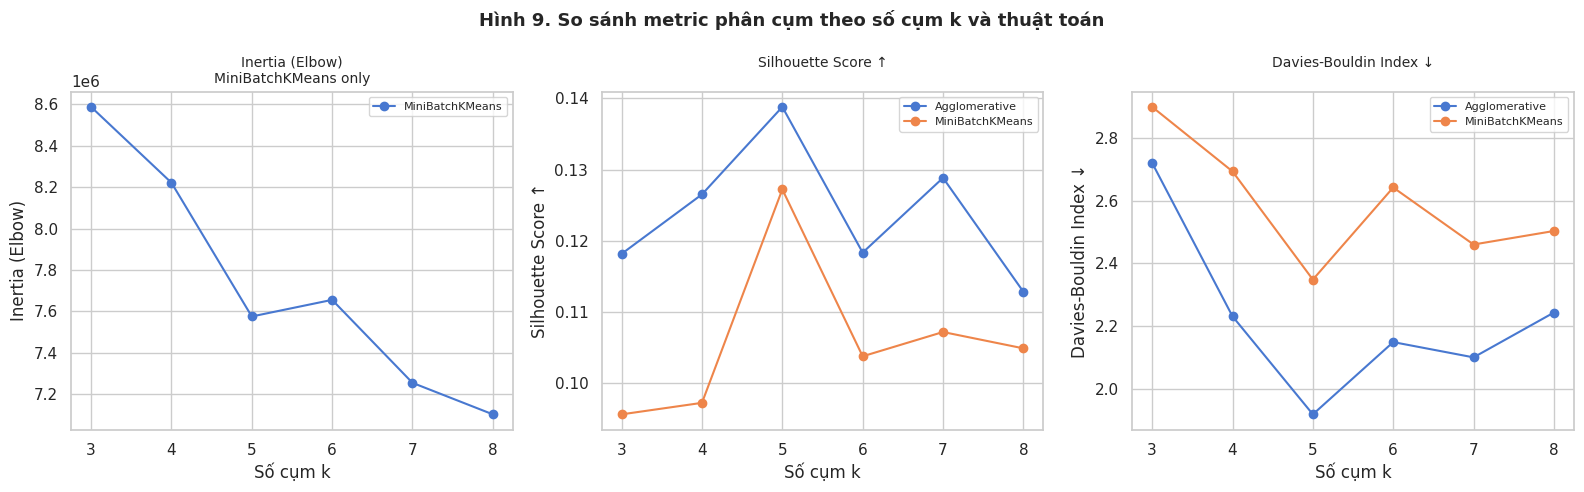

Nhận xét: Dựa vào Silhouette Score và Davies-Bouldin Index để chọn k tối ưu.


In [60]:
# ── Hình 9-11: So sánh metric theo k ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metric_info = [
    ("inertia",          "Inertia (Elbow)",         "MiniBatchKMeans only"),
    ("silhouette",       "Silhouette Score ↑",       ""),
    ("davies_bouldin",   "Davies-Bouldin Index ↓",  ""),
]

for ax, (metric, ylabel, note) in zip(axes, metric_info):
    for algo, grp in metrics_df.sort_values("n_clusters").groupby("algorithm"):
        if metric == "inertia" and algo != "MiniBatchKMeans":
            continue
        ax.plot(grp["n_clusters"], grp[metric], marker="o", label=algo)
    ax.set_xlabel("Số cụm k"); ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\n{note}", fontsize=10)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

fig.suptitle("Hình 9. So sánh metric phân cụm theo số cụm k và thuật toán",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig9_metrics_comparison.png", dpi=150)
plt.show()
print("Nhận xét: Dựa vào Silhouette Score và Davies-Bouldin Index để chọn k tối ưu.")


In [61]:
# ── Chọn mô hình cuối ────────────────────────────────────────────────────────
best_row   = metrics_df.iloc[0]
FINAL_ALGO = best_row["algorithm"]
FINAL_K    = int(best_row["n_clusters"])
# FINAL_K    = 8

print(f"Mô hình được chọn: {FINAL_ALGO}, k={FINAL_K}")
print(f"  Silhouette     : {best_row['silhouette']:.4f}")
print(f"  Davies-Bouldin : {best_row['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz: {best_row['calinski_harabasz']:.1f}")

# Lấy mô hình MiniBatchKMeans để predict linh hoạt trên tập lớn
# (Agglomerative không có predict method chuẩn)
final_model = fitted_models[("MiniBatchKMeans", FINAL_K)]
joblib.dump(final_model, MODEL_DIR / "clustering_model.pkl")
print("✅ Lưu: clustering_model.pkl")


Mô hình được chọn: Agglomerative, k=5
  Silhouette     : 0.1388
  Davies-Bouldin : 1.9205
  Calinski-Harabasz: 2469.8
✅ Lưu: clustering_model.pkl


### 4.3 Phân tích đặc điểm từng cụm và gán nhãn

In [62]:
# ── Gán cụm cho tập summary ─────────────────────────────────────────────────
if len(clean_train) > SUMMARY_SAMPLE_ROWS:
    summary_df = clean_train.sample(SUMMARY_SAMPLE_ROWS, random_state=RANDOM_STATE).copy()
else:
    summary_df = clean_train.copy()

X_summary = feature_pipeline.transform(summary_df)
summary_df["cluster"] = final_model.predict(X_summary)


def mode_val(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else "N/A"

cluster_summary = (
    summary_df.groupby("cluster")
    .agg(
        so_mau            = ("cluster",           "size"),
        gia_trung_vi      = ("price",             "median"),
        dien_tich_trung_vi= ("area",              "median"),
        gia_m2_trung_vi   = ("price_per_m2",      "median"),
        so_tang           = ("floor_count",       "median"),
        ty_le_nhieu_tien_ich      = ("has_luxury_amenities","mean"),
        ty_le_binh_dan    = ("is_affordable",     "mean"),
        ty_le_phu_hop_cho_oto   = ("suitable_for_car",  "mean"),
        ty_le_thuong_mai  = ("is_commercial",     "mean"),
        ty_le_gan_bien    = ("near_sea",          "mean"),
        ty_le_cong_cong   = ("has_public_amenities","mean"),
        ty_le_giao_thong  = ("near_transport_hub", "mean")
    )
    .reset_index()
)

# Mode cho cột object
for col in ["property_type_name","province_name"]:
    cluster_summary[f"{col}_mode"] = (
        summary_df.groupby("cluster")[col].agg(mode_val).values
    )

display(cluster_summary)


,cluster,so_mau,gia_trung_vi,dien_tich_trung_vi,gia_m2_trung_vi,so_tang,ty_le_nhieu_tien_ich,ty_le_binh_dan,ty_le_phu_hop_cho_oto,ty_le_thuong_mai,ty_le_gan_bien,ty_le_cong_cong,ty_le_giao_thong,property_type_name_mode,province_name_mode
0,0,47759,"4,500,000,000.00",110.00,"39,545,454.55",0.00,0.04,0.12,0.30,0.44,0.14,0.47,0.20,Đất,Hồ Chí Minh
1,1,38118,"13,800,000,000.00",51.25,"255,000,000.00",5.00,0.22,0.16,0.61,0.67,0.00,0.51,0.10,Nhà,Hà Nội
2,2,43083,"4,820,000,000.00",72.00,"67,403,314.92",1.00,0.34,0.08,0.10,0.17,0.06,0.50,0.15,Căn hộ chung cư,Hà Nội
3,3,58242,"7,650,000,000.00",69.40,"119,444,444.44",3.00,0.08,0.18,0.41,0.41,0.04,0.48,0.17,Nhà,Hồ Chí Minh
4,4,12798,"19,500,000,000.00",125.00,"154,482,142.86",4.00,0.37,0.07,0.29,0.49,0.11,0.49,0.18,Biệt thự/Nhà liền kề,Hà Nội


In [72]:
# ── Top keywords từ description theo cụm ────────────────────────────────────
def top_terms_per_cluster(df, text_col="description_clean",
                          cluster_col="cluster", top_n=8):
    # ── Stopwords tiếng Việt + từ BĐS quá chung chung ──────────────────────
    vi_stopwords = {
        "và", "của", "các", "có", "với", "là", "được", "trong", "cho",
        "từ", "này", "đã", "về", "không", "một", "những", "đến", "theo",
        # Từ BĐS chung cho mọi cụm → không phân biệt được
        "bán", "giá", "nhà", "đất", "căn", "hộ", "khu", "lô",
        "tô",  "nội",  # artifact tokenization
        "tầng mỗi", "mỗi tầng", "tầng"
    }

    vec = TfidfVectorizer(
        max_features=1000, min_df=5, max_df=0.85, ngram_range=(1, 2)
    )
    X_t   = vec.fit_transform(df[text_col].fillna(""))
    terms = np.array(vec.get_feature_names_out())

    # Điểm trung bình toàn corpus (baseline)
    global_scores = np.asarray(X_t.mean(axis=0)).ravel()

    out = {}
    for c in sorted(df[cluster_col].unique()):
        idx            = df[cluster_col].to_numpy() == c
        cluster_scores = np.asarray(X_t[idx].mean(axis=0)).ravel()

        # Tỷ lệ: từ nào nổi bật HƠN BÌNH THƯỜNG trong cụm này?
        distinctive = cluster_scores / (global_scores + 1e-9)

        # Lọc stopwords và từ 1 ký tự
        mask        = np.array([t not in vi_stopwords and len(t) > 1 for t in terms])
        distinctive = distinctive * mask

        top_idx    = distinctive.argsort()[::-1][:top_n]
        out[int(c)] = ", ".join(terms[top_idx])

    return out

cluster_summary["top_keywords"] = (
    cluster_summary["cluster"]
    .map(top_terms_per_cluster(summary_df))
)

print("=== Top keywords theo cụm ===")
for _, row in cluster_summary.iterrows():
    print(f"\nCụm {int(row['cluster'])} — {row['property_type_name_mode']} — {row['province_name_mode']}")
    print(f"  Giá trung vị: {row['gia_trung_vi']/1e9:.1f} tỷ | DT: {row['dien_tich_trung_vi']:.0f} m²")
    print(f"  Keywords: {row['top_keywords']}")


=== Top keywords theo cụm ===

Cụm 0 — Đất — Hồ Chí Minh
  Giá trung vị: 4.5 tỷ | DT: 110 m²
  Keywords: bán lô, lô đất, nền, xem đất, bán đất, thổ cư, thổ, xã

Cụm 1 — Nhà — Hà Nội
  Giá trung vị: 13.8 tỷ | DT: 51 m²
  Keywords: ngõ thông, wc tầng, tầng thang, mặt phố, tầng phòng, kế tầng, sân phơi, long biên

Cụm 2 — Căn hộ chung cư — Hà Nội
  Giá trung vị: 4.8 tỷ | DT: 72 m²
  Keywords: hộ chung, gym, trẻ em, 1pn, căn hộ, hồ bơi, the, bơi

Cụm 3 — Nhà — Hồ Chí Minh
  Giá trung vị: 7.7 tỷ | DT: 69 m²
  Keywords: btct, cấu trệt, công đầy, lầu sân, hoàn công, sân thượng, hẻm xe, trệt lầu

Cụm 4 — Biệt thự/Nhà liền kề — Hà Nội
  Giá trung vị: 19.5 tỷ | DT: 125 m²
  Keywords: thự, biệt thự, lập, biệt, liền kề, kề, hoàn thiện, tích đất


In [64]:
# ── Gán nhãn thủ công (điền sau khi xem bảng trên) ─────────────────────────
CLUSTER_LABELS = {
    0: "BĐS ở ngoại ô và nông thôn",
    1: "Bất động sản ở khu vực trung tâm",
    2: "Nhà ở xã hội & chung cư tầm trung",
    3: "BĐS gần trung tâm nhưng trong hẻm",
    4: "BĐS hạng sang ở ngoại ô"
    # Thêm/bớt tùy FINAL_K
}
# Cắt bớt nếu FINAL_K < số label
CLUSTER_LABELS = {k: v for k, v in CLUSTER_LABELS.items() if k < FINAL_K}

cluster_summary["nhan_cum"] = cluster_summary["cluster"].map(CLUSTER_LABELS)
summary_df["cluster_label"] = summary_df["cluster"].map(CLUSTER_LABELS)

cluster_summary.to_csv(CLUSTER_SUMMARY_PATH, index=False, encoding="utf-8-sig")
with open(MODEL_DIR / "cluster_labels.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k,v in CLUSTER_LABELS.items()}, f, ensure_ascii=False, indent=2)

print("✅ Đã lưu cluster_summary.csv và cluster_labels.json")
display(cluster_summary[["cluster","nhan_cum","so_mau","gia_trung_vi",
                          "dien_tich_trung_vi","gia_m2_trung_vi",
                          "property_type_name_mode","province_name_mode", "top_keywords"]])


✅ Đã lưu cluster_summary.csv và cluster_labels.json


,cluster,nhan_cum,so_mau,gia_trung_vi,dien_tich_trung_vi,gia_m2_trung_vi,property_type_name_mode,province_name_mode,top_keywords
0,0,BĐS ở ngoại ô và nông thôn,47759,"4,500,000,000.00",110.00,"39,545,454.55",Đất,Hồ Chí Minh,"đất, đường, lô, cư, giá, bán, khu, lô đất"
1,1,Bất động sản ở khu vực trung tâm,38118,"13,800,000,000.00",51.25,"255,000,000.00",Nhà,Hà Nội,"tầng, nhà, phòng, phố, ngõ, tô, mặt, tầng phòng"
2,2,Nhà ở xã hội & chung cư tầm trung,43083,"4,820,000,000.00",72.00,"67,403,314.92",Căn hộ chung cư,Hà Nội,"căn, căn hộ, hộ, nội, và, giá, view, bán"
3,3,BĐS gần trung tâm nhưng trong hẻm,58242,"7,650,000,000.00",69.40,"119,444,444.44",Nhà,Hồ Chí Minh,"nhà, hẻm, công, phòng, lầu, trệt, bán, tân"
4,4,BĐS hạng sang ở ngoại ô,12798,"19,500,000,000.00",125.00,"154,482,142.86",Biệt thự/Nhà liền kề,Hà Nội,"thự, biệt thự, biệt, nhà, tầng, khu, giá, và"


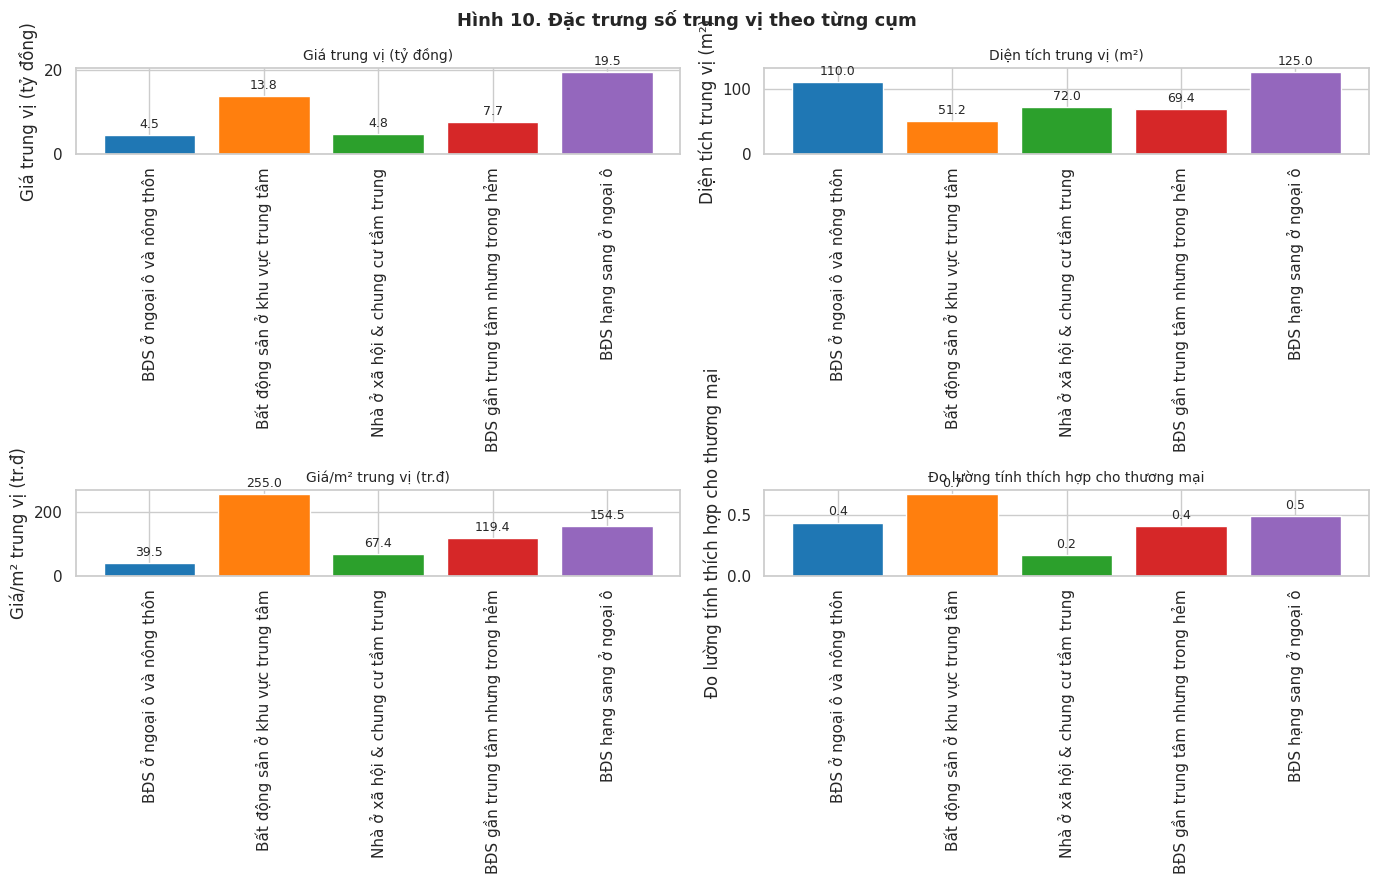

In [65]:
# ── Hình 10: Đặc trưng số theo cụm ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
pairs = [
    ("gia_trung_vi",       "Giá trung vị (tỷ đồng)",  1e9),
    ("dien_tich_trung_vi", "Diện tích trung vị (m²)",  1),
    ("gia_m2_trung_vi",    "Giá/m² trung vị (tr.đ)", 1e6),
    ("ty_le_thuong_mai", "Đo lường tính thích hợp cho thương mại", 1)
]
labels_x = [CLUSTER_LABELS.get(i, f"Cụm {i}") for i in cluster_summary["cluster"]]
for ax, (col, ylabel, div) in zip(axes.flatten(), pairs):
    vals = cluster_summary[col] / div
    bars = ax.bar(labels_x, vals, color=plt.cm.tab10.colors[:len(vals)])
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=10)
    ax.tick_params(axis="x", rotation=90)

fig.suptitle("Hình 10. Đặc trưng số trung vị theo từng cụm",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig10_cluster_numeric_profile.png", dpi=150)
plt.show()


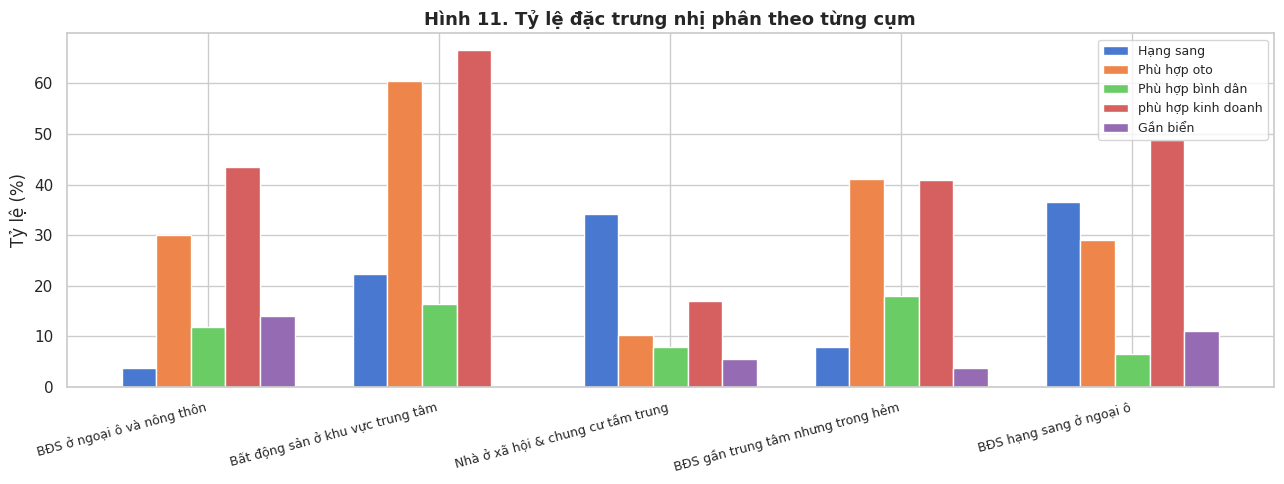

In [66]:
# ── Hình 11: Tỷ lệ đặc trưng nhị phân theo cụm ─────────────────────────────
binary_show = ["ty_le_nhieu_tien_ich","ty_le_phu_hop_cho_oto","ty_le_binh_dan",
               "ty_le_thuong_mai","ty_le_gan_bien"]
binary_labels = ["Hạng sang","Phù hợp oto","Phù hợp bình dân","phù hợp kinh doanh","Gần biển"]

x = np.arange(len(labels_x))
w = 0.15
fig, ax = plt.subplots(figsize=(13, 5))
for i, (col, lbl) in enumerate(zip(binary_show, binary_labels)):
    ax.bar(x + i*w, cluster_summary[col]*100, w, label=lbl)

ax.set_xticks(x + w*2)
ax.set_xticklabels(labels_x, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Tỷ lệ (%)")
ax.legend(fontsize=9)
ax.set_title("Hình 11. Tỷ lệ đặc trưng nhị phân theo từng cụm",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig11_cluster_binary_profile.png", dpi=150)
plt.show()


### 4.4 Trực quan hóa không gian cụm

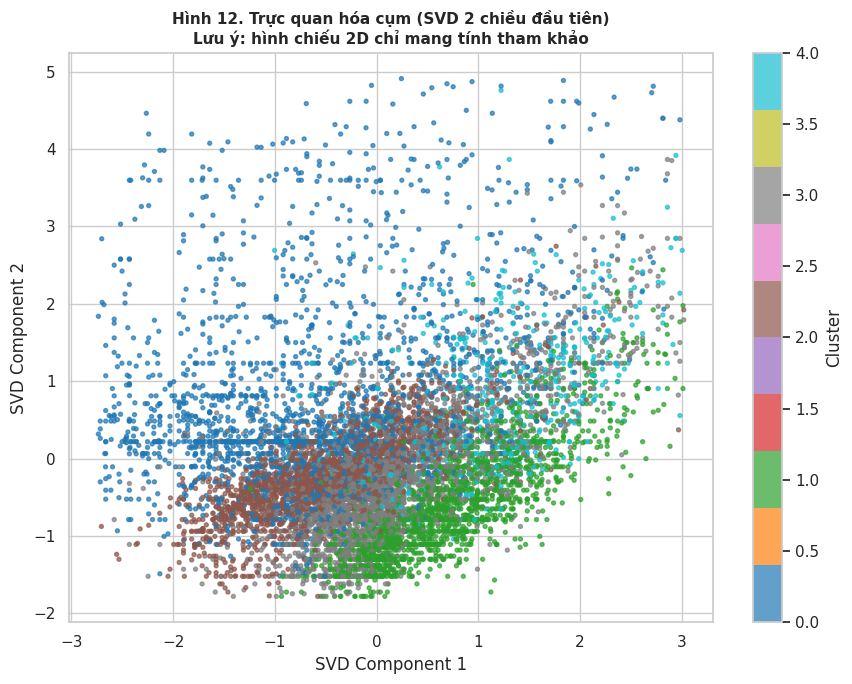

In [67]:
# ── Hình 12: SVD 2D ─────────────────────────────────────────────────────────
labels_model = final_model.predict(X_model)
n_plot = min(10_000, len(X_model))
idx_plot = np.random.default_rng(RANDOM_STATE).choice(len(X_model), n_plot, replace=False)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_model[idx_plot, 0], X_model[idx_plot, 1],
                c=labels_model[idx_plot], cmap="tab10", s=8, alpha=0.7)
plt.colorbar(sc, ax=ax, label="Cluster")
ax.set_xlabel("SVD Component 1"); ax.set_ylabel("SVD Component 2")
ax.set_title("Hình 12. Trực quan hóa cụm (SVD 2 chiều đầu tiên)\n"
             "Lưu ý: hình chiếu 2D chỉ mang tính tham khảo",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig12_svd2d_clusters.png", dpi=150)
plt.show()


Đang chạy t-SNE trên 10,000 mẫu (có thể mất 1–3 phút)...


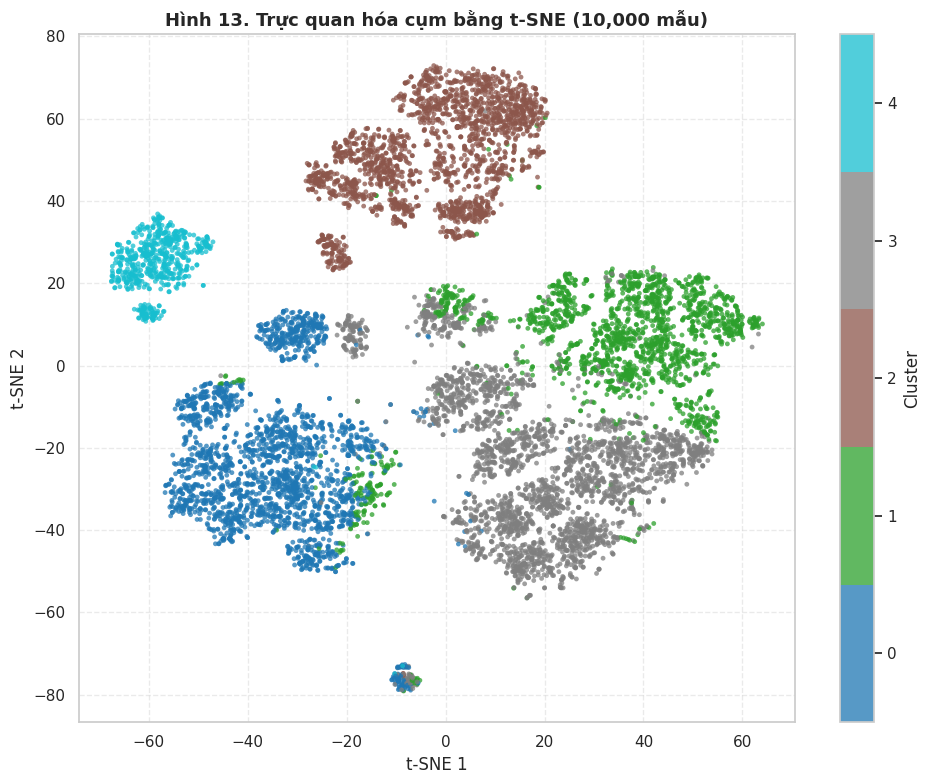

Nhận xét: t-SNE cho thấy các cụm có xu hướng tách biệt trong không gian đặc trưng.


In [68]:

from sklearn.manifold import TSNE

# ── Hình 13: t-SNE (subsample 5,000) ────────────────────────────────────────
TSNE_N = min(10_000, len(X_model))
rng_tsne = np.random.default_rng(RANDOM_STATE)
idx_tsne = rng_tsne.choice(len(X_model), TSNE_N, replace=False)
X_tsne_in = X_model[idx_tsne]
labels_tsne = labels_model[idx_tsne]

print(f"Đang chạy t-SNE trên {TSNE_N:,} mẫu (có thể mất 1–3 phút)...")
# perplexity=60 để các cụm nhìn mạch lạc hơn như đã thảo luận trước đó
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=60, n_iter=1000, init='pca')
X_tsne_2d = tsne.fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 8))

# Lấy chính xác số lượng cụm (k=5)
num_clusters = len(np.unique(labels_tsne))

# Ép dải màu chỉ có đúng num_clusters màu (rời rạc)
cmap = plt.get_cmap("tab10", num_clusters)

# Vẽ scatter với vmin, vmax để căn chỉnh chính xác dải màu
sc = ax.scatter(X_tsne_2d[:,0], X_tsne_2d[:,1],
                c=labels_tsne, cmap=cmap, s=12, alpha=0.75, edgecolors="none",
                vmin=-0.5, vmax=num_clusters - 0.5)

# Colorbar với các ticks là số nguyên
cbar = plt.colorbar(sc, ax=ax, ticks=range(num_clusters), label="Cluster")

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"Hình 13. Trực quan hóa cụm bằng t-SNE ({TSNE_N:,} mẫu)", fontsize=13, fontweight="bold")
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig13_tsne_clusters.png", dpi=150)
plt.show()
print("Nhận xét: t-SNE cho thấy các cụm có xu hướng tách biệt trong không gian đặc trưng.")

## 5. Kết luận – Demo tập kiểm thử

### Demo 10 mẫu ngẫu nhiên từ tập test

Tập test được transform bằng pipeline đã fit từ train (không fit lại), sau đó mô hình dự đoán cụm.


In [74]:
# ── Transform test & predict ─────────────────────────────────────────────────
X_test = feature_pipeline.transform(clean_test)
clean_test["cluster"]       = final_model.predict(X_test)
clean_test["cluster_label"] = clean_test["cluster"].map(CLUSTER_LABELS)

# ── Demo 10 mẫu ──────────────────────────────────────────────────────────────
demo_cols = ["property_type_name","province_name","district_name",
             "price","area","price_per_m2"
             ,"floor_count","cluster","cluster_label"]

demo = clean_test.sample(10, random_state=89).reset_index(drop=True)
demo[demo_cols].to_csv(TEST_DEMO_PATH, index=False, encoding="utf-8-sig")

print("=== Demo 10 mẫu tập kiểm thử ===")
display(demo[demo_cols])
print(f"\n✅ Lưu: {TEST_DEMO_PATH}")


=== Demo 10 mẫu tập kiểm thử ===


,property_type_name,province_name,district_name,price,area,price_per_m2,floor_count,cluster,cluster_label
0,Đất,Hồ Chí Minh,Bình Chánh,"2,400,000,000.00",90.00,"26,666,666.67",0.00,0,BĐS ở ngoại ô và nông thôn
1,Nhà,Hồ Chí Minh,Bình Tân,"6,170,000,000.00",65.00,"94,923,076.92",3.00,3,BĐS gần trung tâm nhưng trong hẻm
2,Đất,Long An,Đức Hòa,"1,100,000,000.00",125.00,"8,800,000.00",0.00,0,BĐS ở ngoại ô và nông thôn
3,Nhà,Hồ Chí Minh,Bình Thạnh,"20,000,000,000.00",112.00,"178,571,428.57",1.00,3,BĐS gần trung tâm nhưng trong hẻm
4,Đất,Hồ Chí Minh,Bình Thạnh,"25,000,000,000.00",186.20,"134,264,232.01",0.00,3,BĐS gần trung tâm nhưng trong hẻm
5,Nhà,Hồ Chí Minh,Bình Thạnh,"2,150,000,000.00",37.00,"58,108,108.11",2.00,3,BĐS gần trung tâm nhưng trong hẻm
6,Đất,Đà Nẵng,Cẩm Lệ,"13,500,000,000.00",200.00,"67,500,000.00",0.00,0,BĐS ở ngoại ô và nông thôn
7,Nhà,Bình Dương,Thuận An,"4,800,000,000.00",60.00,"80,000,000.00",3.00,3,BĐS gần trung tâm nhưng trong hẻm
8,Nhà,Hà Nội,Hoài Đức,"7,250,000,000.00",45.00,"161,111,111.11",5.00,3,BĐS gần trung tâm nhưng trong hẻm
9,Nhà,Hồ Chí Minh,Phú Nhuận,"9,000,000,000.00",77.00,"116,883,116.88",5.00,3,BĐS gần trung tâm nhưng trong hẻm



✅ Lưu: /kaggle/working/reports/test_demo_10_samples.csv


## 6. Tổng kết và hướng phát triển

### Kết quả đạt được
- Đã xây dựng pipeline hoàn chỉnh từ dữ liệu thô đến phân cụm có nhãn.
- So sánh MiniBatchKMeans và Agglomerative Clustering trên 6 giá trị k.
- Đánh giá bằng 3 metric chuẩn: Silhouette, Davies-Bouldin, Calinski-Harabasz.
- Phân tích đặc trưng phổ biến và gán nhãn có ý nghĩa thực tế cho từng cụm.

### Hướng phát triển
- Thử thêm các thuật toán như HDBSCAN để phát hiện cụm hình dạng tự do.
- Tăng cường biểu diễn văn bản bằng embedding (PhoBERT) thay vì TF-IDF.
- Kết hợp dữ liệu địa lý (tọa độ GPS) để cải thiện đặc trưng vị trí.
- Triển khai pipeline dạng streaming để cập nhật mô hình khi có dữ liệu mới.


In [70]:
# ── Kiểm tra toàn bộ file đầu ra ────────────────────────────────────────────
output_files = [
    RAW_TRAIN_PATH, RAW_TEST_PATH,
    CLEAN_TRAIN_PATH, CLEAN_TEST_PATH,
    METRICS_PATH, CLUSTER_SUMMARY_PATH, TEST_DEMO_PATH,
    MODEL_DIR / "feature_pipeline.pkl",
    MODEL_DIR / "clustering_model.pkl",
    MODEL_DIR / "cluster_labels.json",
]

rows = []
for p in output_files:
    rows.append({
        "File": p.name,
        "Tồn tại": "✅" if p.exists() else "❌",
        "Kích thước": f"{p.stat().st_size/1e6:.2f} MB" if p.exists() else "—",
    })

display(pd.DataFrame(rows))
print(f"\nSố hình đã tạo: {len(list(FIGURE_DIR.glob('*.png')))}")

,File,Tồn tại,Kích thước
0,raw_data_train.csv,✅,2915.28 MB
1,raw_data_test.csv,✅,323.99 MB
2,clean_data_train.csv,✅,3482.73 MB
3,clean_data_test.csv,✅,386.57 MB
4,clustering_metrics.csv,✅,0.00 MB
5,cluster_summary.csv,✅,0.00 MB
6,test_demo_10_samples.csv,✅,0.00 MB
7,feature_pipeline.pkl,✅,0.14 MB
8,clustering_model.pkl,✅,1.20 MB
9,cluster_labels.json,✅,0.00 MB



Số hình đã tạo: 15
